# Differential gene expression and GO term enrichment analysis

In [1]:
## The following code ensures that all functions and init files are reloaded before executions.
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
from insitupy import InSituData, CACHE

## Load Xenium data into `InSituData` object

Now the Xenium data can be parsed by providing the data path to the `InSituPy` project folder.

In [3]:
insitupy_project = Path(CACHE / "out/demo_insitupy_project")

In [4]:
xd = InSituData.read(insitupy_project)

In [5]:
xd.load_images()
xd.load_cells()
xd.load_annotations()

## Issue of spill-over effects in imaging-based spatial transcriptomics methods

Imaging-based spatial transcriptomics methods such as Xenium In Situ enable the measurement of RNA at single-molecule resolution. To assign transcripts to individual cells, these methods rely on cell segmentation algorithms. However, due to the complex nature of biological tissues, including densely packed cells, irregular cell shapes, and variable staining intensities, cell segmentation is often challenging, leading to inaccurately drawn cell boundaries. This can result in spill-over effects, where transcripts from one cell are incorrectly assigned to neighboring cells. Consequently, when performing differential gene expression analysis, one cannot always confidently determine whether detected genes were genuinely upregulated in the cells of interest or merely reflected transcript misassignment from adjacent cells. This issue is particularly problematic in regions with closely apposed cell membranes or when analyzing rare cell types surrounded by cells with distinct expression profiles. To mitigate these effects, we recommend comparing target and reference cell populations both against each other and against their respective neighborhoods, thereby distinguishing genuine expression changes from neighborhood-driven spill-over artifacts.

In [6]:
from insitupy.tools.neighbors import mean_gex_diff_to_neighbors, max_gex_diff_to_neighbors

In [7]:
adata = xd.cells.matrix.copy()

In [8]:
results, adj, diffs, qc = mean_gex_diff_to_neighbors(
    adata=adata, celltype_tuple=("cell_type_dc_sub_final", "Stromal cells"),
    radius=20
)

Building spatial graph (radius=20, weighted=False)...
Selected 21022 'Stromal cells' cells as targets
Excluding same-celltype neighbors from adjacency matrix...
Computing mean neighbor expression...
Computing gex_diff = gex_target - gex_neighbor ...
Running paired tests (wilcoxon) per gene and computing effect sizes...


genes: 100%|██████████| 297/297 [00:07<00:00, 39.58it/s]

Applying multiple-testing correction...

ANALYSIS SUMMARY
Target cell type: 'Stromal cells'
Target cells: 21022/156447 (13.4%)
Genes tested: 297
Target cells without neighbors: 0 (0.0%)
Median neighbors per target cell: 2.0



In [9]:
diffs

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(156447, 297))

In [11]:
adata

AnnData object with n_obs × n_vars = 156447 × 297
    obs: 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'n_genes_by_counts', 'n_genes', 'leiden', 'cell_type_dc', 'cell_type_dc_sub', 'cell_type_tacco', 'cell_type_publ_x', 'cell_type_publ_y', 'cell_type_dc_sub_final', 'cell_type_publ'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'cell_type_dc_colors', 'cell_type_dc_sub', 'cell_type_dc_sub_colors', 'cell_type_dc_sub_final_colors', 'cell_type_publ_colors', 'cell_type_tacco_colors', 'counts_location', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'OT', 'X_pca', 'X_umap', 'annotations', 'ora_estimate', 'ora_pvals', 'regions', 'spatial'
    varm: 'OT', 'PCs'
    layers: 'counts', 'norm_counts'
    obsp: 'connectivities', 'distances'

'PTPRC'

In [41]:
# select the gene that is most likely contaminated
gene = results.sort_values("contamination_score", ascending=False).index[0]
adata.obs[f"contamination_{gene}"] = diffs[:, adata.var_names.get_loc(gene)]

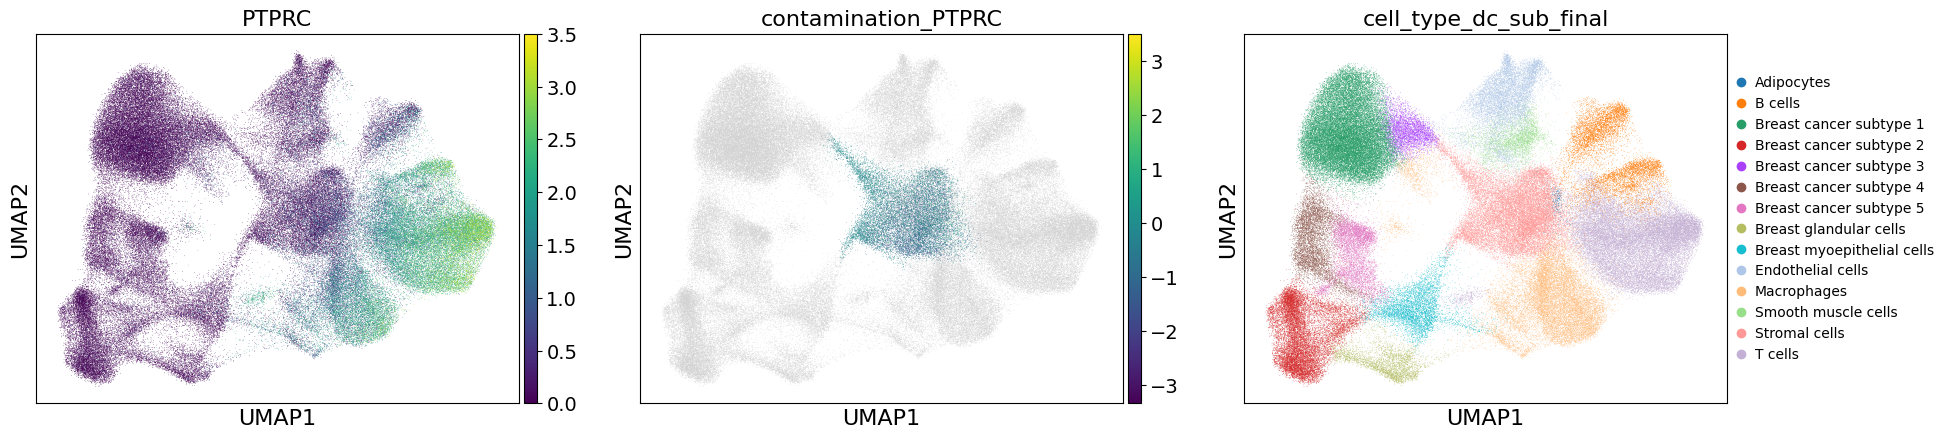

In [42]:
import scanpy as sc
sc.pl.umap(adata, color=[gene, f"contamination_{gene}", "cell_type_dc_sub_final"], vmax=3.5)

## Include the neighborhood contamination info into differential gene expression analysis

In [43]:
from insitupy.tools import dge

In [64]:
dge_results = dge(
    target=xd,
    target_cell_type_tuple=("cell_type_dc_sub_final", "Breast cancer subtype 4"),
    ref_cell_type_tuple=("cell_type_dc_sub_final", "Breast cancer subtype 1"),
    ref=None,
    consider_neighbors=True,
    exclude_ambiguous_assignments=True
    )

Calculate differentially expressed genes with Scanpy's `rank_genes_groups` using 't-test'.
Building spatial graph (radius=20, weighted=False)...
Selected 6445 'Breast cancer subtype 4' cells as targets
Excluding same-celltype neighbors from adjacency matrix...
Computing mean neighbor expression...
Computing gex_diff = gex_target - gex_neighbor ...
Running paired tests (t-test) per gene and computing effect sizes...


genes: 100%|██████████| 297/297 [00:02<00:00, 124.69it/s]


Applying multiple-testing correction...

ANALYSIS SUMMARY
Target cell type: 'Breast cancer subtype 4'
Target cells: 6445/156447 (4.1%)
Genes tested: 297
Target cells without neighbors: 0 (0.0%)
Median neighbors per target cell: 2.0

Building spatial graph (radius=20, weighted=False)...
Selected 31016 'Breast cancer subtype 1' cells as targets
Excluding same-celltype neighbors from adjacency matrix...
Computing mean neighbor expression...
Computing gex_diff = gex_target - gex_neighbor ...
Running paired tests (t-test) per gene and computing effect sizes...


genes: 100%|██████████| 297/297 [00:09<00:00, 31.59it/s]


Applying multiple-testing correction...

ANALYSIS SUMMARY
Target cell type: 'Breast cancer subtype 1'
Target cells: 31016/156447 (19.8%)
Genes tested: 297
Target cells without neighbors: 0 (0.0%)
Median neighbors per target cell: 1.0



In [59]:
dge_results.main

,log2foldchange,pvalue,scores,neg_log10_pvals
gene,,,,
SERPINA3,5.463246,1.000000e-300,122.826881,300.0
CEACAM6,3.637490,1.000000e-300,113.902092,300.0
AGR3,4.773612,1.000000e-300,96.515915,300.0
TACSTD2,1.096257,1.000000e-300,65.303688,300.0
ESR1,2.567329,1.000000e-300,55.416771,300.0
...,...,...,...,...
MDM2,-0.940504,1.000000e-300,-51.063091,300.0
TCIM,-1.277700,1.000000e-300,-54.453094,300.0
KRT7,-0.575407,1.000000e-300,-55.371044,300.0


In [61]:
from insitupy.plotting import dual_foldchange_plot, volcano

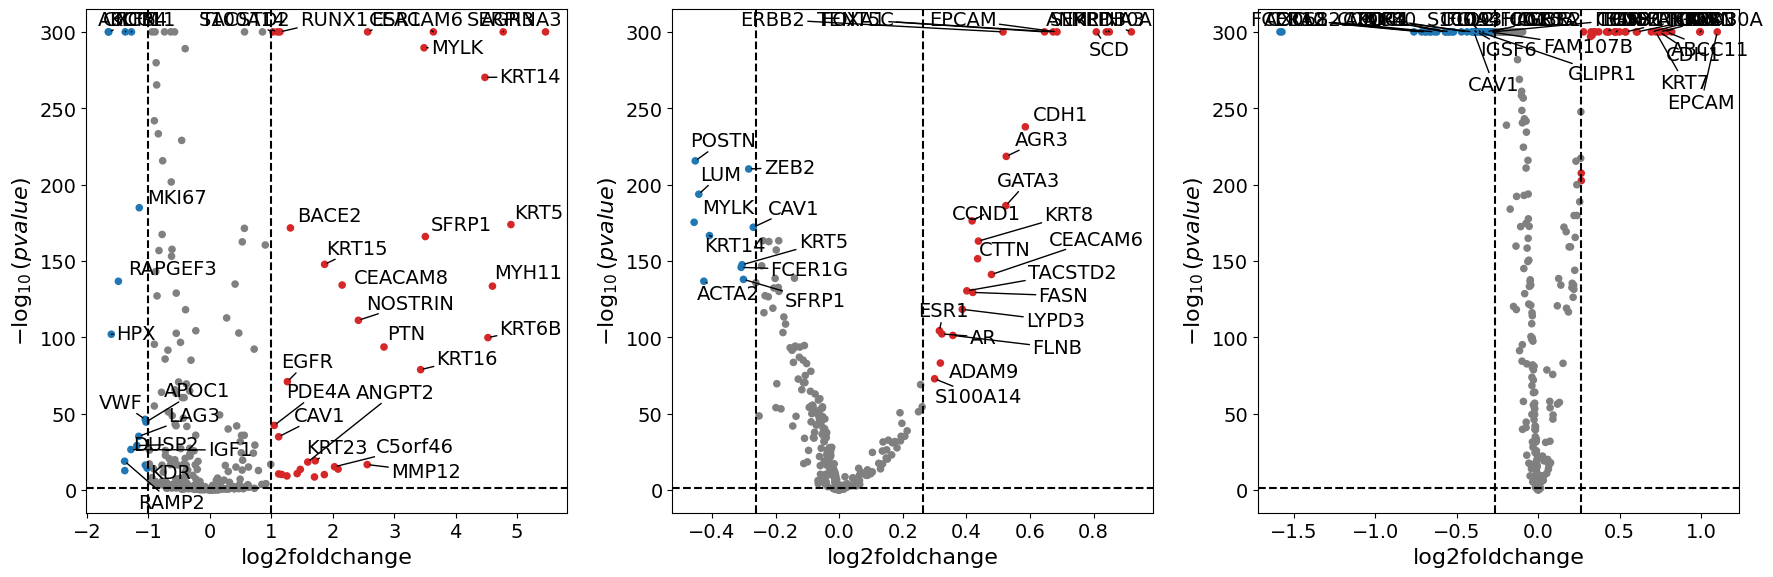

In [62]:
volcano(
    dge_results, #foldchange_threshold=2
    backend="decoupler"
    # adjust_labels=False
    )

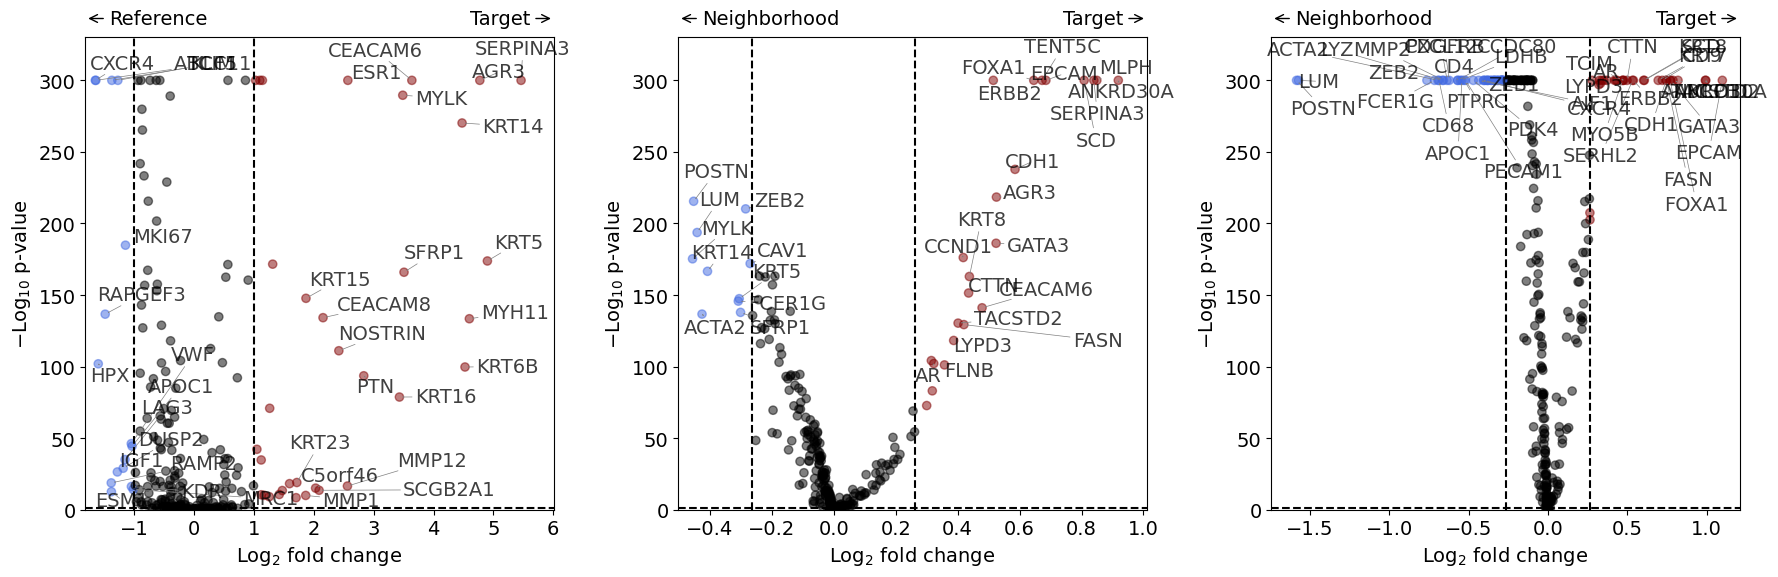

In [83]:
volcano(
    dge_results, #foldchange_threshold=2
    backend="insitupy"
    # adjust_labels=False
    )

In [86]:
dge_results.target_neighborhood

,n_target_cells,n_cells_used,n_cells_expressed,mean_target,mean_neighbor,log2foldchange,log2foldchange_unpaired,pvalue,padj,contamination_score
gene,,,,,,,,,,
ABCC11,6445,5105,2477,0.565558,0.463177,0.147704,0.368266,1.000000e+00,1.000000e+00,-0.221925
ACTA2,6445,5105,2680,0.600571,0.895618,-0.425663,-0.815663,1.024041e-137,1.789060e-136,0.607594
ACTG2,6445,5105,3729,0.922865,0.968523,-0.065870,-0.107717,4.440767e-05,8.347518e-05,0.064398
ADAM9,6445,5105,3792,0.962086,0.741608,0.318083,0.556858,1.000000e+00,1.000000e+00,-0.299489
ADGRE5,6445,5105,129,0.018626,0.071199,-0.075846,-1.972721,8.176986e-64,5.167159e-63,0.639369
...,...,...,...,...,...,...,...,...,...,...
VWF,6445,5105,245,0.037620,0.091385,-0.077567,-1.319651,9.787295e-39,3.726701e-38,0.563628
WARS,6445,5105,2004,0.358330,0.371862,-0.019522,-0.063830,5.897621e-02,9.731075e-02,0.042594
ZEB1,6445,5105,176,0.027682,0.159486,-0.190153,-2.622956,3.060646e-164,1.136265e-162,1.489268


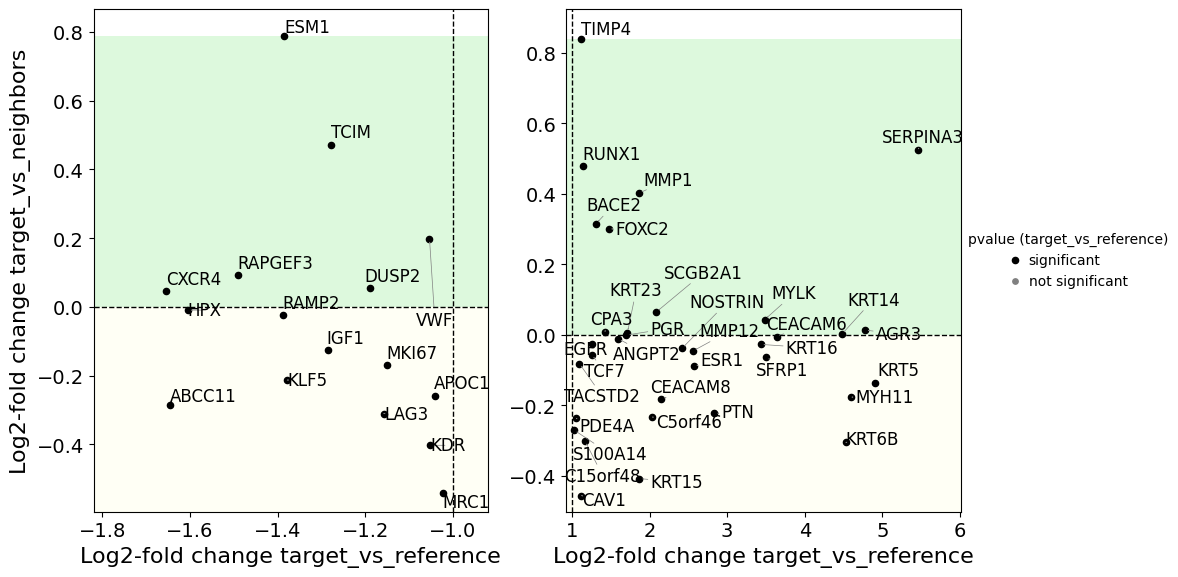

In [ ]:
dual_foldchange_plot(
    dge_results, foldchange_threshold=2
    )

In [72]:
results

,n_target_cells,n_cells_used,n_cells_expressed,mean_target,mean_neighbor,log2foldchange,log2foldchange_unpaired,pvalue,padj,contamination_score
gene,,,,,,,,,,
ABCC11,21022,15065,2216,0.145756,0.200001,-0.078260,-0.496715,5.980412e-70,1.315691e-69,0.318446
ACTA2,21022,15065,11534,1.306177,1.002679,0.437855,0.641619,1.000000e+00,1.000000e+00,-0.311380
ACTG2,21022,15065,9496,0.786381,0.893863,-0.155064,-0.273088,6.227729e-60,1.330673e-59,0.174941
ADAM9,21022,15065,8662,0.663105,0.552661,0.159337,0.350533,1.000000e+00,1.000000e+00,-0.208801
ADGRE5,21022,15065,3218,0.207064,0.350327,-0.206686,-0.866766,2.459438e-221,1.328096e-220,0.673104
...,...,...,...,...,...,...,...,...,...,...
VWF,21022,15065,2746,0.177604,0.328967,-0.218371,-1.003070,7.292712e-221,3.799887e-220,0.786628
WARS,21022,15065,6303,0.459855,0.445946,0.020066,0.055097,8.645237e-01,1.000000e+00,-0.035842
ZEB1,21022,15065,8654,0.699699,0.441720,0.372185,0.867295,1.000000e+00,1.000000e+00,-0.465406


In [ ]:
dge_results.ref_neighborhood

,n_target_cells,n_cells_used,n_cells_expressed,mean_target,mean_neighbor,log2foldchange,log2foldchange_unpaired,pvalue,padj,contamination_score
gene,,,,,,,,,,
ABCC11,31016,17879,14751,1.211318,0.665242,0.787822,1.319181,1.000000,1.000000,-0.600786
ACTA2,31016,17879,9639,0.525261,1.005323,-0.692584,-1.326549,0.000000,0.000000,1.107672
ACTG2,31016,17879,13011,0.858179,0.854385,0.005473,0.009515,0.740975,1.000000,-0.005712
ADAM9,31016,17879,12893,0.852588,0.799903,0.076008,0.135203,1.000000,1.000000,-0.079791
ADGRE5,31016,17879,446,0.018370,0.143971,-0.181204,-3.062200,0.000000,0.000000,1.530831
...,...,...,...,...,...,...,...,...,...,...
VWF,31016,17879,1830,0.079330,0.277080,-0.285294,-1.951254,0.000000,0.000000,1.590893
WARS,31016,17879,8557,0.440672,0.463612,-0.033096,-0.091005,0.000003,0.000004,0.061213
ZEB1,31016,17879,1116,0.049014,0.330657,-0.406326,-2.963661,0.000000,0.000000,2.726766


In [67]:
dge_results = dge(
    target=xd,
    target_annotation_tuple=("Demo", "Tumor cells"),
    ref_annotation_tuple=("Demo", "Stroma"),
    ref=None,
    consider_neighbors=True,
    exclude_ambiguous_assignments=True
    )

Exclude ambiguously assigned cells...
Calculate differentially expressed genes with Scanpy's `rank_genes_groups` using 't-test'.
None


TypeError: 'NoneType' object is not subscriptable

In [43]:
dge_results

<DiffExprResults main=297 genes, neighbors=True>

In [46]:
dge_results.main

,log2foldchange,pvalue,scores,neg_log10_pvals
gene,,,,
TACSTD2,4.258287,1.000000e-300,127.106476,300.0
KRT7,3.639654,1.000000e-300,126.832382,300.0
KRT8,4.133759,1.000000e-300,119.925850,300.0
EPCAM,3.372502,1.000000e-300,112.337814,300.0
GATA3,2.876812,1.000000e-300,102.739853,300.0
...,...,...,...,...
MMP2,-4.745604,1.000000e-300,-104.215431,300.0
POSTN,-4.376478,1.000000e-300,-116.978348,300.0
CCDC80,-5.120635,1.000000e-300,-120.872879,300.0


In [49]:
dge_results.target_neighborhood.sort_values("contamination_score")

,n_target_cells,n_cells_used,n_cells_expressed,mean_target,mean_neighbor,log2foldchange,log2foldchange_unpaired,pvalue,padj,contamination_score
gene,,,,,,,,,,
CCDC80,19695,19671,2397,0.147013,0.133009,0.020203,0.154752,3.374817e-81,6.551116e-81,-0.081789
PDGFRB,19695,19671,1875,0.140825,0.127696,0.018940,0.150867,2.304674e-48,3.492286e-48,-0.078648
POSTN,19695,19671,4953,0.386759,0.361704,0.036147,0.115823,2.610201e-53,4.101744e-53,-0.074260
LUM,19695,19671,6140,0.455742,0.430344,0.036642,0.102398,1.646249e-33,2.295474e-33,-0.065934
ZEB1,19695,19671,1776,0.109903,0.100547,0.013498,0.135225,9.793921e-63,1.634154e-62,-0.064304
...,...,...,...,...,...,...,...,...,...,...
AGR3,19695,19671,8323,0.453985,0.459087,-0.007360,-0.020082,1.069462e-14,1.351618e-14,0.013286
MLPH,19695,19671,14529,1.252172,1.265849,-0.019732,-0.027557,7.605273e-01,8.213695e-01,0.014593
ANKRD30A,19695,19671,15349,1.566894,1.583894,-0.024526,-0.030925,9.927726e-01,1.000000e+00,0.014713


In [50]:
dge_results.ref_neighborhood.sort_values("contamination_score")

,n_target_cells,n_cells_used,n_cells_expressed,mean_target,mean_neighbor,log2foldchange,log2foldchange_unpaired,pvalue,padj,contamination_score
gene,,,,,,,,,,
EPCAM,11713,10029,3181,0.356572,0.329499,0.039058,0.134563,7.812378e-01,8.437368e-01,-0.085547
ANKRD30A,11713,10029,5135,0.628232,0.585067,0.062275,0.136963,9.993327e-01,1.000000e+00,-0.085515
S100A14,11713,10029,2291,0.223658,0.207062,0.023943,0.123631,1.762726e-01,2.136856e-01,-0.073975
FOXA1,11713,10029,3689,0.463608,0.435531,0.040506,0.111895,9.802901e-01,1.000000e+00,-0.071870
TACSTD2,11713,10029,3011,0.323359,0.302493,0.030104,0.112073,4.517414e-01,5.062913e-01,-0.071108
...,...,...,...,...,...,...,...,...,...,...
MS4A1,11713,10029,716,0.101887,0.105560,-0.005298,-0.053779,5.467261e-18,2.029721e-16,0.026243
CD19,11713,10029,421,0.044034,0.046707,-0.003857,-0.086983,9.593895e-18,3.165985e-16,0.026780
CLEC14A,11713,10029,1160,0.159148,0.163975,-0.006963,-0.046677,1.139923e-06,3.193936e-06,0.026869


In [ ]:
dge_results.target_neighborhood.sort_values("contamination_score")

,n_target_cells,n_cells_used,n_cells_expressed,mean_target,mean_neighbor,log2foldchange,log2foldchange_unpaired,pvalue,padj,contamination_score
gene,,,,,,,,,,
CCDC80,19695,19671,2397,0.147013,0.133009,0.020203,0.154752,3.374817e-81,6.551116e-81,-0.081789
PDGFRB,19695,19671,1875,0.140825,0.127696,0.018940,0.150867,2.304674e-48,3.492286e-48,-0.078648
POSTN,19695,19671,4953,0.386759,0.361704,0.036147,0.115823,2.610201e-53,4.101744e-53,-0.074260
LUM,19695,19671,6140,0.455742,0.430344,0.036642,0.102398,1.646249e-33,2.295474e-33,-0.065934
ZEB1,19695,19671,1776,0.109903,0.100547,0.013498,0.135225,9.793921e-63,1.634154e-62,-0.064304
...,...,...,...,...,...,...,...,...,...,...
AGR3,19695,19671,8323,0.453985,0.459087,-0.007360,-0.020082,1.069462e-14,1.351618e-14,0.013286
MLPH,19695,19671,14529,1.252172,1.265849,-0.019732,-0.027557,7.605273e-01,8.213695e-01,0.014593
ANKRD30A,19695,19671,15349,1.566894,1.583894,-0.024526,-0.030925,9.927726e-01,1.000000e+00,0.014713


In [37]:
results

,n_target_cells,n_cells_used,n_cells_expressed,mean_target,mean_neighbor,log2_fold_change_paired,log2_fold_change,p_value,p_adj,contamination_score
gene,,,,,,,,,,
ABCC11,21022,15065,2216,0.145756,0.200001,-0.078260,-0.496715,5.980412e-70,1.315691e-69,0.318446
ACTA2,21022,15065,11534,1.306177,1.002679,0.437855,0.641619,1.000000e+00,1.000000e+00,-0.311380
ACTG2,21022,15065,9496,0.786381,0.893863,-0.155064,-0.273088,6.227729e-60,1.330673e-59,0.174941
ADAM9,21022,15065,8662,0.663105,0.552661,0.159337,0.350533,1.000000e+00,1.000000e+00,-0.208801
ADGRE5,21022,15065,3218,0.207064,0.350327,-0.206686,-0.866766,2.459438e-221,1.328096e-220,0.673104
...,...,...,...,...,...,...,...,...,...,...
VWF,21022,15065,2746,0.177604,0.328967,-0.218371,-1.003070,7.292712e-221,3.799887e-220,0.786628
WARS,21022,15065,6303,0.459855,0.445946,0.020066,0.055097,8.645237e-01,1.000000e+00,-0.035842
ZEB1,21022,15065,8654,0.699699,0.441720,0.372185,0.867295,1.000000e+00,1.000000e+00,-0.465406


In [ ]:
dge_results

In [15]:
dge_results

<DiffExprResults main=297 genes, neighbors=False>

In [18]:
dge_results.main

,log2foldchange,pvalue,scores,neg_log10_pvals
gene,,,,
TACSTD2,4.258287,1.000000e-300,228.485779,300.0
KRT7,3.639654,1.000000e-300,206.441269,300.0
KRT8,4.133759,1.000000e-300,206.435577,300.0
EPCAM,3.372502,1.000000e-300,170.650497,300.0
CDH1,3.154814,1.000000e-300,142.136597,300.0
...,...,...,...,...
MMP2,-4.745604,1.000000e-300,-139.529953,300.0
POSTN,-4.376478,1.000000e-300,-174.575211,300.0
CXCL12,-5.083491,1.000000e-300,-182.173859,300.0


In [19]:
results

,n_target_cells,n_cells_used,n_cells_expressed,mean_target,mean_neighbor,log2_fold_change_paired,log2_fold_change,p_value,p_adj,contamination_score
gene,,,,,,,,,,
ABCC11,21022,15065,2216,0.145756,0.200001,-0.078260,-0.496715,5.980412e-70,1.315691e-69,0.318446
ACTA2,21022,15065,11534,1.306177,1.002679,0.437855,0.641619,1.000000e+00,1.000000e+00,-0.311380
ACTG2,21022,15065,9496,0.786381,0.893863,-0.155064,-0.273088,6.227729e-60,1.330673e-59,0.174941
ADAM9,21022,15065,8662,0.663105,0.552661,0.159337,0.350533,1.000000e+00,1.000000e+00,-0.208801
ADGRE5,21022,15065,3218,0.207064,0.350327,-0.206686,-0.866766,2.459438e-221,1.328096e-220,0.673104
...,...,...,...,...,...,...,...,...,...,...
VWF,21022,15065,2746,0.177604,0.328967,-0.218371,-1.003070,7.292712e-221,3.799887e-220,0.786628
WARS,21022,15065,6303,0.459855,0.445946,0.020066,0.055097,8.645237e-01,1.000000e+00,-0.035842
ZEB1,21022,15065,8654,0.699699,0.441720,0.372185,0.867295,1.000000e+00,1.000000e+00,-0.465406


In [ ]:
from insitupy.plotting import volcano

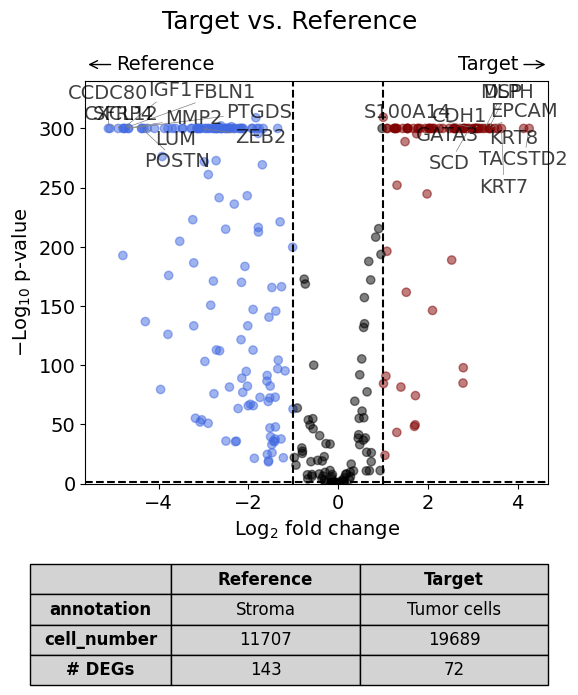

In [ ]:
volcano(
    dge_results,
    label_sortby="scores",
    label_top_n=10,
    title="Target vs. Reference",
    show_config=True
    )

## Idea for possible further improvements of the contamination score

Currently the contamination score is based on the logfoldchange between target and neighbor cells and the mean expression in the neighbor cells. In addition one could also include the "stability" of the expression in the target cells and the neighbor cells. As stability measure one could use the standard deviations.

So a final score could look like this:

`-results['log2_gradient_paired'] / (results['mean_target'] / results['std_target'] * results['std_neighbors'] + epsilon)`

This would include the stability as follows:
- A high stability (low std) of the target cells would result in a lower contamination score
- A high stability (low std) of the neighboring cells would result in a higher contamination score

Claude suggests a better approach using the coefficient of variation:

```Python
# CV = std/mean (normalized variability)
cv_target = results['std_target'] / (results['mean_target'] + epsilon)
cv_neighbors = results['std_neighbors'] / (results['mean_neighbors'] + epsilon)

# Low CV in target (stable) reduces contamination
# High CV in neighbors (unstable) reduces contamination confidence
results['contamination_score'] = (
    -results['log2_fold_change_paired'] / 
    (results['mean_target'] + epsilon) *
    (1 + cv_target) *  # Penalty for unstable target
    (1 / (1 + cv_neighbors))  # Penalty for unstable neighbors
)
```

Should first proceed with the current contamination score.

# Important note about the `max_` function: In the current version, the statistical test is wrong since it assumes a mean of 0 in the null distribution, which is not the case when using the max difference. To make the statistical test correct one has to implement a permutation test! One big thing of this could be that we could get a estimated contamination score for each cell! This we could then use to correct the gene expression and "clean" the cluster

In [35]:
results_max, adj_max, diffs_max, qc_max = max_gex_diff_to_neighbors(
    adata=adata, celltype_col="cell_type_dc_sub_final", celltype="Stromal cells",
    radius=20
)

Building spatial graph (radius=20, weighted=False)...
Selected 21022 'Stromal cells' cells as targets
Excluding same-celltype neighbors from adjacency matrix...
156447
Computing max neighbor expression (per-gene maximum)...


cells: 100%|██████████| 21022/21022 [00:23<00:00, 895.07it/s] 


Computing gex_diff = gex_target - gex_neighbor_max ...
Running paired tests (wilcoxon) per gene and computing effect sizes...


genes: 100%|██████████| 297/297 [00:06<00:00, 43.42it/s]


Applying multiple-testing correction...

ANALYSIS SUMMARY
Target cell type: 'Stromal cells'
Target cells: 21022/156447 (13.4%)
Genes tested: 297
Target cells without neighbors: 0 (0.0%)
Median neighbors per target cell: 2.0



In [36]:
results

,n_target_cells,n_cells_used,n_cells_expressed,mean_target,mean_neighbor,log2_fold_change_paired,log2_fold_change,p_value,p_adj,contamination_score
gene,,,,,,,,,,
ABCC11,21022,15065,2216,0.145756,0.200001,-0.078260,-0.496715,5.980412e-70,1.315691e-69,0.318446
ACTA2,21022,15065,11534,1.306177,1.002679,0.437855,0.641619,1.000000e+00,1.000000e+00,-0.311380
ACTG2,21022,15065,9496,0.786381,0.893863,-0.155064,-0.273088,6.227729e-60,1.330673e-59,0.174941
ADAM9,21022,15065,8662,0.663105,0.552661,0.159337,0.350533,1.000000e+00,1.000000e+00,-0.208801
ADGRE5,21022,15065,3218,0.207064,0.350327,-0.206686,-0.866766,2.459438e-221,1.328096e-220,0.673104
...,...,...,...,...,...,...,...,...,...,...
VWF,21022,15065,2746,0.177604,0.328967,-0.218371,-1.003070,7.292712e-221,3.799887e-220,0.786628
WARS,21022,15065,6303,0.459855,0.445946,0.020066,0.055097,8.645237e-01,1.000000e+00,-0.035842
ZEB1,21022,15065,8654,0.699699,0.441720,0.372185,0.867295,1.000000e+00,1.000000e+00,-0.465406


In [40]:
results.sort_values("contamination_score", ascending=False).head(10)

,n_target_cells,n_cells_used,n_cells_expressed,mean_target,mean_neighbor,log2_fold_change_paired,log2_fold_change,p_value,p_adj,contamination_score
gene,,,,,,,,,,
PTPRC,21022,15065,3987,0.279241,0.952284,-0.970996,-2.304802,0.0,0.0,2.560368
CYTIP,21022,15065,2095,0.132856,0.504424,-0.536059,-2.207006,0.0,0.0,2.302108
CD3E,21022,15065,2721,0.184148,0.554796,-0.534732,-1.874872,0.0,0.0,1.881875
IL2RG,21022,15065,2382,0.154740,0.455101,-0.433329,-1.783996,0.0,0.0,1.701066
SMAP2,21022,15065,3098,0.189433,0.526254,-0.485931,-1.731493,0.0,0.0,1.678908
CXCR4,21022,15065,5860,0.449991,1.050990,-0.867057,-1.710954,0.0,0.0,1.576492
GZMA,21022,15065,1180,0.075734,0.261814,-0.268458,-1.927538,0.0,0.0,1.527638
CD93,21022,15065,2753,0.176126,0.459363,-0.408624,-1.598136,0.0,0.0,1.479847
IL7R,21022,15065,3310,0.239885,0.585908,-0.499204,-1.555049,0.0,0.0,1.468743


In [37]:
results_max

,n_target_cells,n_cells_used,n_cells_expressed,mean_target,mean_neighbor_max,log2_gradient_paired,log2_gradient,p_value,p_adj,contamination_score
gene,,,,,,,,,,
ABCC11,21022,15065,2216,0.145756,0.481699,-0.484663,-1.979555,0.000000e+00,0.000000e+00,1.972135
ACTA2,21022,15065,11534,1.306177,1.710432,-0.583216,-0.751245,0.000000e+00,0.000000e+00,0.414753
ACTG2,21022,15065,9496,0.786381,1.522884,-1.062550,-1.584610,0.000000e+00,0.000000e+00,1.198751
ADAM9,21022,15065,8662,0.663105,1.114731,-0.651558,-1.122768,0.000000e+00,0.000000e+00,0.853825
ADGRE5,21022,15065,3218,0.207064,0.850666,-0.928523,-2.543444,0.000000e+00,0.000000e+00,3.023877
...,...,...,...,...,...,...,...,...,...,...
VWF,21022,15065,2746,0.177604,0.829995,-0.941202,-2.734323,0.000000e+00,0.000000e+00,3.390452
WARS,21022,15065,6303,0.459855,0.999393,-0.778389,-1.555926,0.000000e+00,0.000000e+00,1.390341
ZEB1,21022,15065,8654,0.699699,0.996877,-0.428738,-0.754991,4.773462e-279,6.563510e-279,0.536124


In [26]:
results.sort_values("log2_fold_change_paired", ascending=True).head(10)

,n_cells_used,n_cells_expressed,mean_target,mean_neighbor,log2_fold_change_paired,log2_fold_change,p_value,p_adj
gene,,,,,,,,
PTPRC,21022,6274,0.287330,0.682435,-0.570016,-1.555920,0.000000e+00,0.000000e+00
CXCR4,21022,8741,0.445954,0.753171,-0.443220,-0.999698,0.000000e+00,0.000000e+00
CYTIP,21022,3210,0.131353,0.361485,-0.332010,-1.633298,0.000000e+00,0.000000e+00
CD3E,21022,4310,0.189149,0.397584,-0.300709,-1.229433,0.000000e+00,0.000000e+00
CD4,21022,7936,0.371229,0.558142,-0.269659,-0.733556,8.184385e-223,1.869817e-221
SMAP2,21022,4757,0.190786,0.377130,-0.268837,-1.123876,0.000000e+00,0.000000e+00
IL2RG,21022,3691,0.154744,0.326139,-0.247270,-1.204185,0.000000e+00,0.000000e+00
PECAM1,21022,6579,0.299805,0.468196,-0.242936,-0.772308,8.498700e-203,1.402286e-201
IL7R,21022,5427,0.257078,0.419879,-0.234872,-0.831812,2.195741e-187,2.964251e-186


In [ ]:
results

,n_cells_used,n_cells_expressed,mean_target,mean_neighbor,log2_fold_change_paired,log2_fold_change,p_value,p_adj
gene,,,,,,,,
ABCC11,15065,2216,0.145756,0.200001,-0.078260,-0.496715,5.980412e-70,1.315691e-69
ACTA2,15065,11534,1.306177,1.002679,0.437855,0.641619,1.000000e+00,1.000000e+00
ACTG2,15065,9496,0.786381,0.893863,-0.155064,-0.273088,6.227729e-60,1.330673e-59
ADAM9,15065,8662,0.663105,0.552661,0.159337,0.350533,1.000000e+00,1.000000e+00
ADGRE5,15065,3218,0.207064,0.350327,-0.206686,-0.866766,2.459438e-221,1.328096e-220
...,...,...,...,...,...,...,...,...
VWF,15065,2746,0.177604,0.328967,-0.218371,-1.003070,7.292712e-221,3.799887e-220
WARS,15065,6303,0.459855,0.445946,0.020066,0.055097,8.645237e-01,1.000000e+00
ZEB1,15065,8654,0.699699,0.441720,0.372185,0.867295,1.000000e+00,1.000000e+00


In [53]:
results

,n_cells_used,n_cells_expressed,mean_target,mean_neighbor,log2_fold_change_paired,log2_fold_change,p_value,p_adj
gene,,,,,,,,
ABCC11,21022,3657,0.157971,0.145399,0.018138,0.128944,9.999161e-01,1.000000e+00
ACTA2,21022,16600,1.251058,0.718396,0.768469,1.246528,1.000000e+00,1.000000e+00
ACTG2,21022,14069,0.796917,0.642863,0.222253,0.434263,1.000000e+00,1.000000e+00
ADAM9,21022,13030,0.685152,0.397109,0.415558,1.013309,1.000000e+00,1.000000e+00
ADGRE5,21022,4764,0.202295,0.250505,-0.069553,-0.344467,1.031505e-37,3.978661e-37
...,...,...,...,...,...,...,...,...
VWF,21022,4623,0.191783,0.236088,-0.063919,-0.332952,3.260111e-16,1.030056e-15
WARS,21022,8911,0.425158,0.320010,0.151696,0.490428,1.000000e+00,1.000000e+00
ZEB1,21022,12471,0.669138,0.315921,0.509585,1.358352,1.000000e+00,1.000000e+00


In [28]:
results

,n_cells_used,mean_diff,std_diff,cohen_d,rank_biserial,stat,p_value,p_adj,significant,contamination_flag
gene,,,,,,,,,,
ABCC11,15065,-0.054246,0.460983,-0.117674,0.935998,7263273.5,5.980412e-70,1.315691e-69,True,True
ACTA2,15065,0.303498,0.949455,0.319655,0.365644,71989649.0,1.000000e+00,1.000000e+00,False,False
ACTG2,15065,-0.107482,0.813973,-0.132046,0.612906,43929275.0,6.227729e-60,1.330673e-59,True,True
ADAM9,15065,0.110444,0.750495,0.147162,0.508220,55809525.5,1.000000e+00,1.000000e+00,False,False
ADGRE5,15065,-0.143264,0.561241,-0.255262,0.836322,18574884.5,2.459438e-221,1.328096e-220,True,True
...,...,...,...,...,...,...,...,...,...,...
VWF,15065,-0.151363,0.579229,-0.261318,0.905774,10693242.0,7.292712e-221,3.799887e-220,True,True
WARS,15065,0.013909,0.673425,0.020654,0.646944,40066439.0,8.645237e-01,1.000000e+00,False,False
ZEB1,15065,0.257979,0.769859,0.335099,0.471764,59946691.0,1.000000e+00,1.000000e+00,False,False


In [32]:
results, adj, diffs, qc = estimate_neighborhood_contamination(
    adata=adata, radius=20, neighbor_summary="max"
)

Building radius-neighbor graph (radius=20 µm)...
Neighbor graph: (156447, 156447), mean degree=7.50, zero-degree cells=5723
Computing neighbor-maximum expression (memory-efficient, may take longer)...


cells: 100%|██████████| 157/157 [01:01<00:00,  2.56it/s]


Computing gex_diff = gex_target - gex_neighbor ...
Running paired tests (wilcoxon) per gene and computing effect sizes...


genes: 100%|██████████| 297/297 [00:06<00:00, 46.17it/s]


Applying multiple-testing correction...

ANALYSIS SUMMARY
Cells analyzed: 156447
Genes tested: 297
Cells without neighbors: 5723 (3.7%)
Median neighbors per cell: 7.0
Significant genes: 297
Contamination candidates: 297

Storing results in adata...


In [33]:
results, adj, diffs, qc = estimate_neighborhood_contamination(
    adata=adata, radius=20, neighbor_summary="max"
)

Building radius-neighbor graph (radius=20 µm)...
Neighbor graph: (156447, 156447), mean degree=7.50, zero-degree cells=5723
Computing neighbor-maximum expression...


cells: 100%|██████████| 156447/156447 [00:04<00:00, 34435.70it/s]


Computing gex_diff = gex_target - gex_neighbor ...
Running paired tests (wilcoxon) per gene and computing effect sizes...


genes: 100%|██████████| 297/297 [00:06<00:00, 45.37it/s]

Applying multiple-testing correction...

ANALYSIS SUMMARY
Cells analyzed: 156447
Genes tested: 297
Cells without neighbors: 5723 (3.7%)
Median neighbors per cell: 7.0
Significant genes: 297
Contamination candidates: 297

Storing results in adata...


In [34]:
results

,n_cells_used,mean_diff,std_diff,cohen_d,rank_biserial,stat,p_value,p_adj,significant,contamination_flag
gene,,,,,,,,,,
ABCC11,97044,-0.965949,0.718870,-1.343704,0.970305,139826892.5,0.0,0.0,True,True
ACTA2,146015,-1.061600,0.906807,-1.170701,0.954813,481705934.0,0.0,0.0,True,True
ACTG2,146694,-0.939396,0.830488,-1.131138,0.949941,538617661.0,0.0,0.0,True,True
ADAM9,142091,-0.909705,0.739133,-1.230773,0.956530,438832192.5,0.0,0.0,True,True
ADGRE5,88314,-1.057363,0.713873,-1.481164,0.978921,82201289.0,0.0,0.0,True,True
...,...,...,...,...,...,...,...,...,...,...
VWF,82002,-1.190870,0.874387,-1.361948,0.977352,76146975.0,0.0,0.0,True,True
WARS,138301,-0.933093,0.721479,-1.293306,0.963984,344448762.0,0.0,0.0,True,True
ZEB1,98118,-1.035431,0.736827,-1.405256,0.970168,143600545.0,0.0,0.0,True,True


## Conclusion

Using the "MAX" approach apparently all the cells seem to be possible contamination sources. Not sure if this makes sense. Does selecting the max expression in the neighborhood violate the assumption that the expected gradient should be zero, since we always pick the extreme cases and therefore it is more likely that the gene expression difference is not zero? 

Should also make sure that the computation is correct. Maybe one can ask Claude for a minimal example to check it.

Claude suggests to either:
1. use a permutation test to check the actual zero distribution and generate a robust p-value, or
2. use the max version only for calculating the effect size and not for the p-value. P-value would be calculated based on the mean neighbor expression and effect size based on the maximum gene expression gradient.

Permutation test would be of course much slower! But maybe worth it to correctly estimate the contamination?

## More points to consider regarding the DGE analysis

- **Negative cell markers**: Could it be that the approach would also identify genes that are simply "negative gene markers" for that cell type? If we just compare the target cells with their neighborhood and check which genes show a significant negative gene expression gradient from the target cells to the neighboring cells, this could also stem from negative gene markers which are simply always less expressed in the target cells compared to any other cell (this applies both for the paired and the non-paired version). **In the DGE analysis plot this would not be an issue since we use the results only for genes from which we know already that they are upregulated in the target cells compared to some other population. So those should not be per se negative cell markers for that cell type**.
- **Max value version**: This is something that we do not really need for the "dual foldchange plot". In the dual fold-change plot we just want to know in addition to the fold-change between target and reference, also the fold-change between target and its neighboring cells. And doing here a paired instead of an unpaired test should be more exact, since the connection between target cells and neighborhoods is known. The max value version is rather something that might be interesting when we try to correct the data using the information. However, the big issue with the max approach is that we do not know the zero distribution and have to estimate this using e.g. a permutation test
- **Genes with zero expression in the target cells**: Do we need to add that genes with zero expression in the target cells get excluded from the analysis? There might be the case that such a gene shows a significant negative gene expression gradient compared to the neighboring cells because they always show a higher expression. However, this would not be a contamination since it is actually not found in the target cells. **However, those genes would be also never up-regulated between the target cells and the reference cells, and would therefore never be interesting anyway. So in combination with the DGE analysis between target and reference this is irrelevant.**
- **What about target cells that are surrounded by other target cells?** Would I then only take the non-target neighboring cells into account? For the differential gene expression analysis the contamination between target cells and target cells does not really play a role. So I could just remove target cells from the neighborhood graph.

## Suggestion for implementation

I would suggest to implement three modes for determining the gene expression difference between the target cells and their neighborhood:
1. Unpaired DGE analysis between target cells and neighboring cells (using `rank_genes_groups`)
2. Paired DGE analysis between target cells and the mean expression in the respective neighborhood. The neighborhood would be defined as the mean expression of all (non-target) neighboring cells within a certain radius.
3. Paired DGE analysis between target cells and the maximum expression in the neighborhood. The neighborhood would be defined as the maximum expression of each gene of all (non-target) neighboring cells. Problem here is that the zero distribution is not clear. So one has to do a permutation test, where all the target cells are shuffled (neighboring cells stay the same) and then the mean of the resulting null distribution for each gene is compared against the mean of the observed max expression difference for each gene. The p-value is then the fraction of cases in which the observed mean value shows an even more negative gene expression gradient than the mean of the null distribution (assuming gex_target - gex_nb). The effect size could then be standardized against the null distribution with `standardized_effect = (observed_mean - null_mean) / null_sd`.


Important: In all of these cases we are interested mostly into "negative gene expression gradients" (gex_target - gex_nb), where genes are higher in the neighboring cells than in the target cells. Positive gene expression gradients are for the DGE analysis not relevant. Also for the cleaning of the clusters, mostly the negative gene expression gradients are interesting.


### How to use that information to clean the gene expression vectors of a cluster
In option 3, one has to calculate the mean of the observed max expression difference and the null distribution, etc. But in reality we would get for every target cell an individual max expression difference and also an individual null distribution. So in theory we could get for each individual cell and every gene in that cell the information about how strong the gene expression gradient to the neighboring cells is and a null distribution of the permutation test. So one could calculate a standardized effect size and a p-value for each individual cell. Could we use this information to iteratively change the gene expression of each target cell using the effect size and after each iteration test whether the gradient is still significant different.

In [ ]:
def permutation_test_with_cell_types(
    A_ct,
    X_dense,
    cell_types,
    target_cell_type,
    n_permutations=1000
):
    """
    Permutation test for spatial contamination in one cell type.

    Shuffles only cells of target_cell_type among themselves,
    keeping other cell types in their original positions.
    """
    n_cells, n_genes = X_dense.shape

    # Identify target cells
    target_mask = (cell_types == target_cell_type)
    target_indices = np.where(target_mask)[0]

    if len(target_indices) == 0:
        raise ValueError(f"No cells found with type {target_cell_type}")

    # Compute observed statistics (only for target cells)
    observed = compute_max_neighbor_diffs_for_cells(
        A_ct, X_dense, target_indices
    )

    # Null distribution via permutation
    null_dist = np.zeros((n_genes, n_permutations))

    for perm in tqdm(range(n_permutations)):
        # Create permutation: shuffle only target cells
        perm_idx = np.arange(n_cells)
        perm_target = np.random.permutation(target_indices)
        perm_idx[target_indices] = perm_target

        # Apply permutation
        X_perm = X_dense[perm_idx, :]

        # Compute stats on permuted data (only for target cells)
        # Note: target_indices still refer to the SPATIAL positions
        # but now have different expression profiles
        null_dist[:, perm] = compute_max_neighbor_diffs_for_cells(
            A_ct, X_perm, target_indices
        )

    # P-values
    p_values = np.mean(null_dist <= observed[:, None], axis=1)

    return p_values, null_dist, observed

def compute_max_neighbor_diffs_for_cells(A_ct, X_dense, cell_indices):
    """
    Compute mean max-neighbor differences for specified cells only.
    """
    n_genes = X_dense.shape[1]
    all_diffs = []

    for i in cell_indices:
        start, end = A_ct.indptr[i], A_ct.indptr[i+1]
        nb_indices = A_ct.indices[start:end]

        if len(nb_indices) == 0:
            continue

        neighbor_exprs = X_dense[nb_indices, :]
        max_neighbor = np.max(neighbor_exprs, axis=0)
        diff = X_dense[i, :] - max_neighbor
        all_diffs.append(diff)

    # Mean difference across target cells
    return np.mean(all_diffs, axis=0)
```

## Visual Example
```
Original data:
Position:  [1]  [2]  [3]  [4]  [5]  [6]  [7]  [8]
Cell type:  T    B    T    M    T    B    T    M
CD19 expr:  2    9    3    1    2    8    3    1

Target: T cells (positions 1,3,5,7)

Permutation (shuffle only T cells):
Position:  [1]  [2]  [3]  [4]  [5]  [6]  [7]  [8]
Cell type:  T    B    T    M    T    B    T    M
CD19 expr:  3    9    2    1    3    8    2    1
            ^         ^         ^         ^
            └─────────┴─────────┴─────────┘
            T cells shuffled among themselves

B and M cells (positions 2,4,6,8) unchanged!

Now test if T cell expression patterns are preserved after shuffling.

Permutation test also offers a way to calculate a standardized effect size (Claude called it "Standardized Effect Relative to Null Distribution"):

In [ ]:
# Observed mean difference
observed_mean = np.mean(observed_diffs)

# Null distribution means from permutations
null_means = [np.mean(perm_diffs) for each permutation]

# Standardized effect size
null_mean = np.mean(null_means)
null_sd = np.std(null_means)

standardized_effect = (observed_mean - null_mean) / null_sd

In [ ]:
results

,n_cells_used,mean_diff,std_diff,cohen_d,rank_biserial,stat,p_value,p_adj,significant,contamination_flag
gene,,,,,,,,,,
ABCC11,150724,0.000690,0.534384,0.001291,0.786235,2.428143e+09,2.897782e-33,3.388351e-33,True,False
ACTA2,150724,0.007854,0.772741,0.010163,0.522583,5.422952e+09,7.428490e-09,7.964843e-09,True,False
ACTG2,150724,0.004705,0.751276,0.006263,0.513121,5.530429e+09,7.699489e-02,7.858242e-02,False,False
ADAM9,150724,0.003935,0.658300,0.005978,0.543689,5.183206e+09,1.143789e-15,1.248916e-15,True,False
ADGRE5,150724,-0.000944,0.503492,-0.001875,0.829049,1.941819e+09,6.144436e-257,1.042799e-256,True,True
...,...,...,...,...,...,...,...,...,...,...
VWF,150724,-0.000151,0.522912,-0.000290,0.867281,1.507545e+09,0.000000e+00,0.000000e+00,True,True
WARS,150724,0.002282,0.610628,0.003737,0.573264,4.847264e+09,8.338173e-56,1.014933e-55,True,False
ZEB1,150724,0.005914,0.534250,0.011070,0.788286,2.404848e+09,4.558350e-186,7.014662e-186,True,False


## Idea

Instead of taking the average expression of the neighboring cells, one could calculate the expression difference for each of the neighboring cells independently, then choose the highest gradient for each gene and test this maximum expression gradient. This might make it more sensitive, since otherwise multiple cells in the neighborhood could dilute the contamination signals.

Plus, I am not sure whether it is correct to take the average expression on the log-level or if I would have to work on the counts level and renormalize the data (this would probably make everything a lot more complicated).

Here is a suggestion from ChatGPT how to implement this:

Chat: https://chatgpt.com/c/68fb6ff3-ea90-8333-b5f3-0946474a9cd8

In [ ]:
import numpy as np
from scipy import sparse

def max_neighbor_expression(A_ct, X):
    """
    Compute maximum neighbor gene expression per cell.
    A_ct: sparse adjacency (n_cells x n_cells)
    X: dense (n_cells x n_genes)
    """
    n_cells = A_ct.shape[0]
    n_genes = X.shape[1]
    max_expr = np.full((n_cells, n_genes), np.nan)

    for i in range(n_cells):
        start, end = A_ct.indptr[i], A_ct.indptr[i+1]
        nb_indices = A_ct.indices[start:end]
        if len(nb_indices) == 0:
            continue  # leave as NaN
        max_expr[i] = np.max(X[nb_indices, :], axis=0)
    return max_expr


To speed up the process, I could run it maybe in the end only for the significantly differentially expressed genes instead of all? The downside would be that I would have to specify the significance threshold during DGE computation already instead of doing this after the computation during plotting. However, 0.05 is such an established threshold, that this should not be an issue.

## Further idea on using the contamination information for correcting the data

Could we use the contamination results for correcting the data? For calculating the contamination we now just need a cell type (or transcriptomically similar cluster). We then calculate a gene expression difference/gradient to the surrounding cells and check how much different the result is compared to cells that are far away. This should give us enough information to clean the data. Plus we could run it iteratively over all clusters and one-by-one clean the clusters. This could be e.g. an optimization approach which changes the gene expression of the respective cluster using the effect size/gradient per gene as a measure for how much to change it. After a change, one can recalculate the metrics, check if they improved and do this until the results converge.

Open questions:
1. On what level should I change the data? On the log-normalized data or do I do this best on the raw data and then re-normalize everything again?
2. How efficient is this? Can I make it more efficient by running each cluster on a separate core?

In [30]:
res

,n_cells_used,mean_diff,std_diff,cohen_d,stat,p_value,p_adj,significant,contamination_flag
gene,,,,,,,,,
ABCC11,150724,0.000690,0.534384,0.001291,2.428143e+09,2.897782e-33,3.388351e-33,True,False
ACTA2,150724,0.007854,0.772741,0.010163,5.422952e+09,7.428490e-09,7.964843e-09,True,False
ACTG2,150724,0.004705,0.751276,0.006263,5.530429e+09,7.699489e-02,7.858242e-02,False,False
ADAM9,150724,0.003935,0.658300,0.005978,5.183206e+09,1.143789e-15,1.248916e-15,True,False
ADGRE5,150724,-0.000944,0.503492,-0.001875,1.941819e+09,6.144436e-257,1.042799e-256,True,True
...,...,...,...,...,...,...,...,...,...
VWF,150724,-0.000151,0.522912,-0.000290,1.507545e+09,0.000000e+00,0.000000e+00,True,True
WARS,150724,0.002282,0.610628,0.003737,4.847264e+09,8.338173e-56,1.014933e-55,True,False
ZEB1,150724,0.005914,0.534250,0.011070,2.404848e+09,4.558350e-186,7.014662e-186,True,False


In [36]:
res[res.contamination_flag]["cohen_d"]

gene
ADGRE5     -0.001875
ANGPT2     -0.002000
ANKRD29    -0.003832
APOBEC3B   -0.000969
AQP1       -0.002279
              ...   
TCF7       -0.000724
TENT5C     -0.000682
TIGIT      -0.000510
TOP2A      -0.000722
VWF        -0.000290
Name: cohen_d, Length: 81, dtype: float64

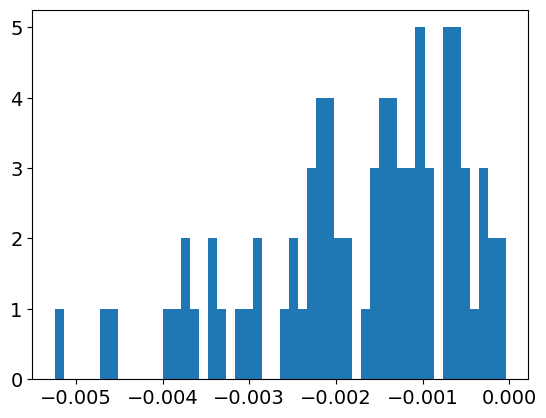

In [35]:
plt.hist(res[res.contamination_flag]["cohen_d"], bins=50)
plt.show()

In [139]:
avg_expr2[0]

matrix([[0.       , 0.       , 0.       , 0.       , 0.       ,
         0.       , 0.       , 0.       , 0.       , 0.       ,
         0.       , 0.       , 0.       , 0.       , 0.       ,
         2.4350743, 0.       , 0.       , 0.       , 0.       ,
         0.       , 0.       , 0.       , 0.       , 0.       ,
         0.       , 0.       , 0.       , 0.       , 0.       ,
         0.       , 0.       , 2.4350743, 0.       , 0.       ,
         0.       , 0.       , 0.       , 0.       , 0.       ,
         0.       , 0.       , 2.4350743, 0.       , 0.       ,
         0.       , 0.       , 0.       , 0.       , 0.       ,
         0.       , 2.4350743, 0.       , 0.       , 0.       ,
         0.       , 0.       , 0.       , 0.       , 0.       ,
         0.       , 0.       , 0.       , 0.       , 2.4350743,
         0.       , 0.       , 0.       , 0.       , 0.       ,
         0.       , 0.       , 0.       , 0.       , 0.       ,
         0.       , 0.       , 0.       

In [154]:
ids = np.array([i for i, expr in enumerate(avg_expr2) if expr is not None])

In [155]:
ids

array([    0,     9,    10, ..., 21001, 21003, 21004], shape=(5346,))

In [157]:
avg_expr2[9]

matrix([[0.       , 0.       , 2.0485642, 0.       , 0.       ,
         0.       , 0.       , 0.       , 1.4766784, 0.       ,
         0.       , 0.       , 0.       , 0.       , 0.       ,
         1.4766784, 0.       , 0.       , 0.       , 0.       ,
         0.       , 0.       , 0.       , 0.       , 2.8843477,
         0.       , 0.       , 0.       , 0.       , 0.       ,
         0.       , 0.       , 0.       , 0.       , 0.       ,
         0.       , 0.       , 0.       , 0.       , 3.0573103,
         1.4766784, 0.       , 0.       , 0.       , 0.       ,
         0.       , 0.       , 0.       , 0.       , 0.       ,
         0.       , 0.       , 0.       , 0.       , 0.       ,
         0.       , 0.       , 0.       , 0.       , 0.       ,
         0.       , 0.       , 0.       , 1.4766784, 0.       ,
         0.       , 0.       , 0.       , 0.       , 0.       ,
         0.       , 0.       , 0.       , 0.       , 0.       ,
         0.       , 0.       , 0.       

In [ ]:
avg_expr.toarray()[9, :]

array([0.        , 0.        , 2.0485642 , 0.        , 0.        ,
       0.        , 0.        , 0.        , 1.47667837, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       1.47667837, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 2.88434768,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 3.05731034,
       1.47667837, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 1.47667837, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [123]:

import numpy as np

# Sum of expressions for each group
sum_expr = A_ct @ X

# Number of neighbors per row
counts = A_ct.sum(axis=1).A1  # .A1 flattens to 1D array

# Avoid division by zero
avg_expr = np.divide(sum_expr.T, counts, where=counts != 0).T


In [124]:
avg_expr

array([<Compressed Sparse Column sparse matrix of dtype 'float64'
       	with 389373 stored elements and shape (297, 21022)>      , None,
       None, ..., None, None, None], shape=(21022,), dtype=object)

In [121]:
avg_expr

[matrix([[0.       , 0.       , 0.       , 0.       , 0.       ,
          0.       , 0.       , 0.       , 0.       , 0.       ,
          0.       , 0.       , 0.       , 0.       , 0.       ,
          2.4350743, 0.       , 0.       , 0.       , 0.       ,
          0.       , 0.       , 0.       , 0.       , 0.       ,
          0.       , 0.       , 0.       , 0.       , 0.       ,
          0.       , 0.       , 2.4350743, 0.       , 0.       ,
          0.       , 0.       , 0.       , 0.       , 0.       ,
          0.       , 0.       , 2.4350743, 0.       , 0.       ,
          0.       , 0.       , 0.       , 0.       , 0.       ,
          0.       , 2.4350743, 0.       , 0.       , 0.       ,
          0.       , 0.       , 0.       , 0.       , 0.       ,
          0.       , 0.       , 0.       , 0.       , 2.4350743,
          0.       , 0.       , 0.       , 0.       , 0.       ,
          0.       , 0.       , 0.       , 0.       , 0.       ,
          0.       , 0.  

In [ ]:
adata[mask_ct][cell_id].obsm["spatial"]

ArrayView([[842.84078369,  16.5410965 ]])

In [85]:
adata[nb_mask].obsm["spatial"]

ArrayView([[827.01093445, 432.35446625],
           [823.6401947 , 404.95825653],
           [814.69667358, 428.97425842],
           [817.26311951, 420.228685  ]])

In [ ]:
A[mask_ct][0, :]

View of AnnData object with n_obs × n_vars = 156447 × 297
    obs: 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'n_genes_by_counts', 'n_genes', 'leiden', 'cell_type_dc', 'cell_type_dc_sub', 'cell_type_tacco', 'cell_type_publ_x', 'cell_type_publ_y', 'cell_type_dc_sub_final', 'cell_type_publ'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'cell_type_dc_colors', 'cell_type_dc_sub', 'cell_type_dc_sub_colors', 'cell_type_dc_sub_final_colors', 'cell_type_publ_colors', 'cell_type_tacco_colors', 'counts_location', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'OT', 'X_pca', 'X_umap', 'annotations', 'ora_estimate', 'ora_pvals', 'regions', 'spatial'
    varm: 'OT', 'PCs'
    layers: 'counts', 'norm_counts'
    obsp: 'connectivities', 'distances'

In [23]:
A

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 173360 stored elements and shape (156447, 156447)>

In [ ]:
A[mask_ct].getnnz(axis=0) > 0

array([False, False, False, ..., False, False, False], shape=(156447,))

In [ ]:
A[mask_ct].astype(bool)

<Compressed Sparse Row sparse matrix of dtype 'bool'
	with 9023 stored elements and shape (21022, 156447)>

In [ ]:
A[mask_ct].astype(bool).sum(axis=0).A1

array([0, 0, 0, ..., 0, 0, 0], shape=(156447,))

In [ ]:
A[mask_ct].astype(bool).sum(axis=1).A1

array([1, 0, 0, ..., 0, 0, 0], shape=(21022,))

In [ ]:
A[mask_ct].astype(bool).sum(axis=0).A1 > 0

array([False, False, False, ..., False, False, False], shape=(156447,))

In [21]:
A.getnnz(axis=0)

array([0, 0, 0, ..., 0, 0, 0], shape=(156447,))

In [22]:
A.getnnz(axis=1)

array([0, 0, 0, ..., 0, 0, 0], shape=(156447,), dtype=int32)

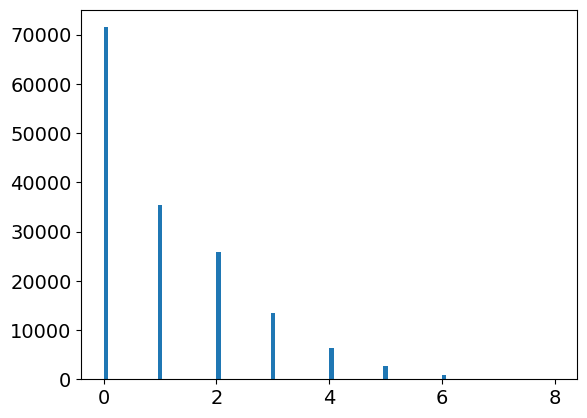

In [19]:
plt.hist(A.getnnz(axis=0), bins=100)
plt.show()

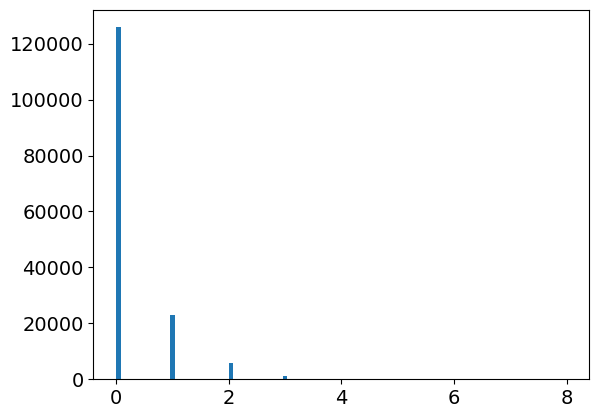

In [ ]:
plt.hist(A[mask_ct].getnnz(axis=0), bins=100)
plt.show()

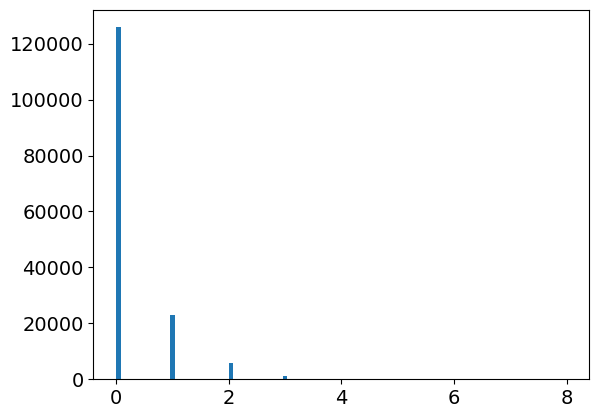

In [ ]:
plt.hist(A[mask_ct].getnnz(axis=0), bins=100)
plt.show()

In [ ]:
np.sum(A[mask_ct][:, 6].toarray() > 0)

np.int64(0)

In [ ]:
np.sum(A[mask_ct][6, :].toarray() > 0)

np.int64(5)

In [ ]:
A[mask_ct][0]

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 5 stored elements and shape (1, 156447)>

In [ ]:
any_mask = A[mask_ct].getnnz(axis=0) > 0

In [80]:
any_mask

array([False, False, False, ..., False, False, False], shape=(156447,))

### Scenario 2: Comparison of two annotations within one dataset - restrict analysis to a specific region

Calculate differentially expressed genes with Scanpy's `rank_genes_groups` using 't-test'.


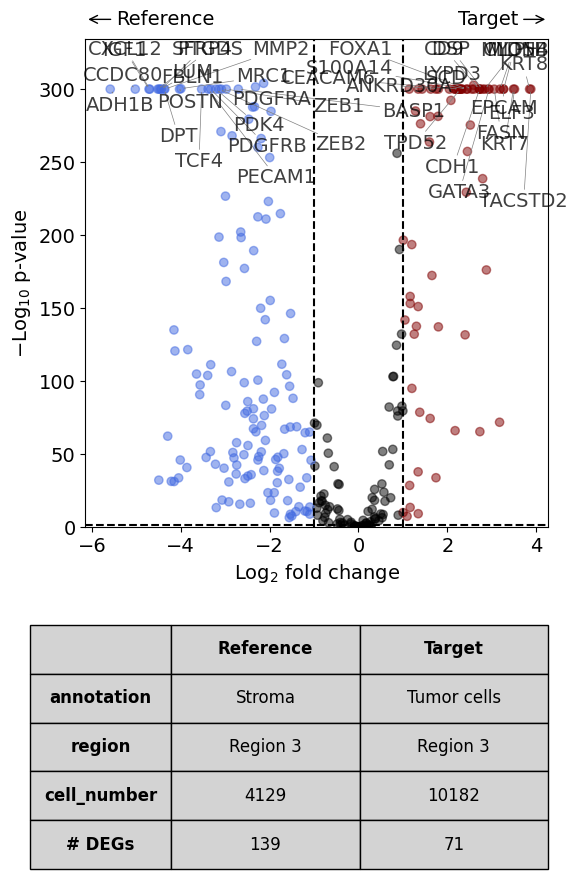

In [ ]:
dge_results = dge(
    target=xd,
    target_annotation_tuple=("Demo", "Tumor cells"),
    ref_annotation_tuple=("Demo", "Stroma"),
    ref=None,
    target_region_tuple=("Demo", "Region 3"),
    ref_region_tuple="same",
    exclude_ambiguous_assignments=True, # if a cell is assigned to both the annotation and the reference, it is used only for the annotation
)

volcano(dge_results, label_sortby="scores", show_config=True)

### Scenario 3: Comparison of two different cell types each in a different annotation within one dataset

This is the analysis shown in the publication in Figure 3F.

Calculate differentially expressed genes with Scanpy's `rank_genes_groups` using 't-test'.


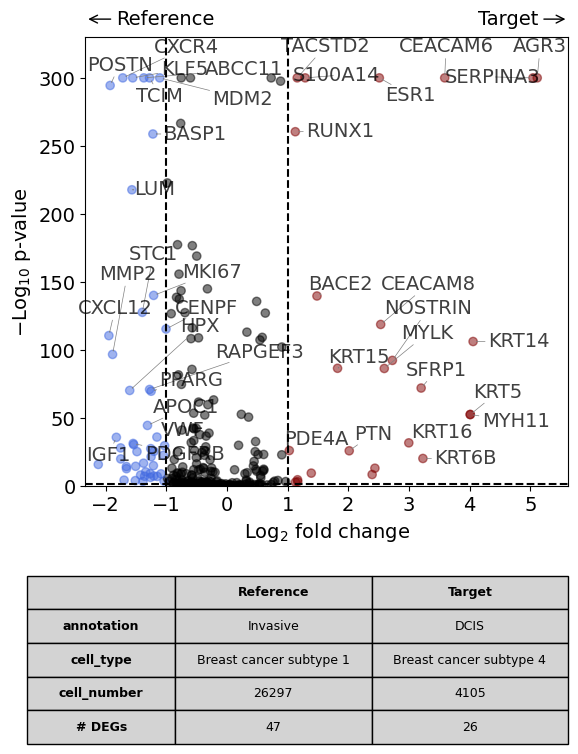

In [ ]:
dge_results = dge(
    target=xd,
    target_cell_type_tuple=("cell_type_dc_sub_final", "Breast cancer subtype 4"),
    target_annotation_tuple=("Katja", "DCIS"),
    ref_cell_type_tuple=("cell_type_dc_sub_final", "Breast cancer subtype 1"),
    ref_annotation_tuple=("Katja", "Invasive"),
    ref=None,
    exclude_ambiguous_assignments=True, # if a cell is assigned to both the annotation and the reference, it is used only for the annotation
)

volcano(dge_results, label_sortby="scores", show_config=True)

### Scenario 4: Comparison of the same cell type in two different regions within one dataset

This is the analysis shown in the publication in Figure 3H.

In [110]:
xd.load_regions()

C:\Users\ge37voy\Github\InSituPy\insitupy\dataclasses\io.py:230: UserWarning: No 'color' column found in the imported data. Setting all colors to red.
  data.add_data(data=f, key=k,
C:\Users\ge37voy\Github\InSituPy\insitupy\dataclasses\io.py:230: UserWarning: No 'color' column found in the imported data. Setting all colors to red.
  data.add_data(data=f, key=k,
C:\Users\ge37voy\Github\InSituPy\insitupy\dataclasses\io.py:230: UserWarning: No 'color' column found in the imported data. Setting all colors to red.
  data.add_data(data=f, key=k,
C:\Users\ge37voy\Github\InSituPy\insitupy\dataclasses\io.py:230: UserWarning: No 'color' column found in the imported data. Setting all colors to red.
  data.add_data(data=f, key=k,


In [111]:
xd.regions

demo_regions:	3 regions, 3 classes ('Region1', 'Region2', 'Region3') ✔
TMA:	6 regions, 6 classes ('A-1', 'A-2', 'A-3', 'B-1', 'B-2', 'B-3') ✔
Demo:	3 regions, 3 classes ('Region 1', 'Region 2', 'Region 3') ✔
Katja:	4 regions, 4 classes ('Region 1', 'Region 2', 'Region 3', 'Region 4') ✔

Calculate differentially expressed genes with Scanpy's `rank_genes_groups` using 't-test'.


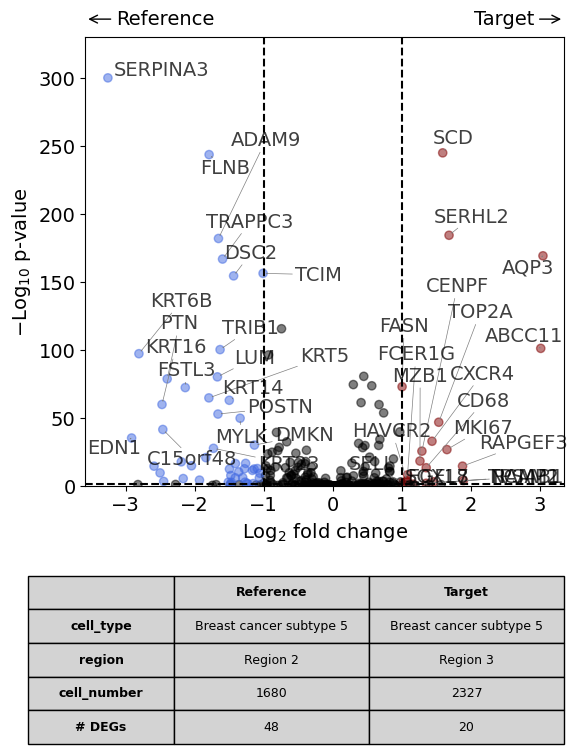

In [ ]:
dge_results = dge(
    target=xd,
    target_cell_type_tuple=("cell_type_dc_sub_final", "Breast cancer subtype 5"),
    target_region_tuple=("Katja", "Region 3"),
    ref_cell_type_tuple="same",
    ref_region_tuple=("Katja", "Region 2"),
    ref=None,
    exclude_ambiguous_assignments=True, # if a cell is assigned to both the annotation and the reference, it is used only for the annotation
)

volcano(dge_results, label_sortby="scores", show_config=True)

## Experiment-level differential gene expression analysis

The clear structure of `InSituExperiment` lets us easily plan complex differential gene expression analysis across multiple samples. In the following, different Scenarios are shown how this can be done.

For more information on the `InSituExperiment` object see [here](../03_multisample_analysis/InSituPy_InSituExperiment.ipynb).

### Creating `InSituExperiment` object

In a first step the region annotations are used to split the dataset and create a `InSituExperiment` object.

In [114]:
from insitupy import InSituExperiment

In [119]:
exp = InSituExperiment.from_regions(
    data=xd,
    region_key="Demo",
    region_names=None # defaults to all regions
)
print(exp)

Region 1
Region 2
Region 3
You are accessing a copy of the metadata. Changes to this DataFrame will not affect the internal metadata. Use `add_metadata_column()` or `append_metadata()` to add new information to metadata.
InSituExperiment with 3 samples:
           uid  CITAR slide_id    sample_id region_key region_name
0     d4604f2f  ++-++  0001879  Replicate 1       Demo    Region 1
1     724eed1f  ++-++  0001879  Replicate 1       Demo    Region 2
2     e7843434  ++-++  0001879  Replicate 1       Demo    Region 3


#### Scenario 1: Comparison of cell types between two samples

##### Scenario 1.1: Using the `InSituData` objects

First, the datasets of interest are extracted from the `InSituExperiment` object and subsequently processed using the `dge` function. In contrast to the previous examples we use now two different datasets.

In [121]:
xd0 = exp.data[0]
xd1 = exp.data[1]
xd2 = exp.data[2]

##### With one reference dataset

Calculate differentially expressed genes with Scanpy's `rank_genes_groups` using 't-test'.


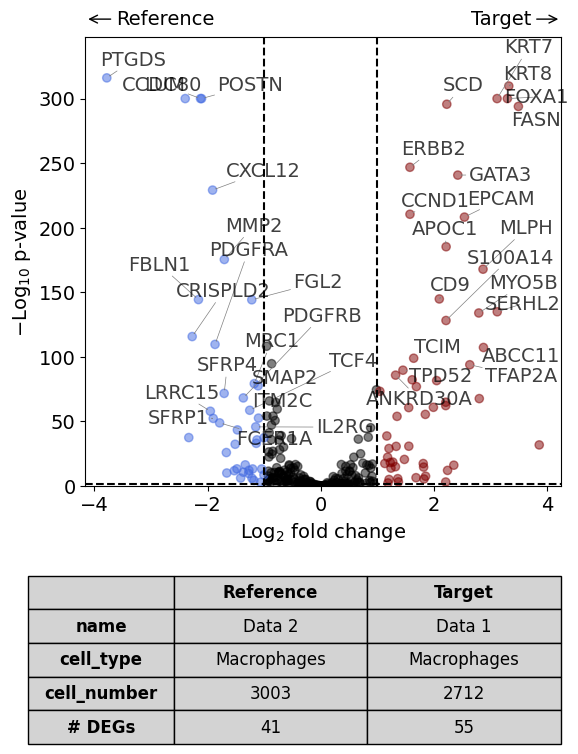

In [ ]:
dge_results = dge(
    target=xd0,
    ref=xd1,
    target_name="Data 1",
    ref_name="Data 2",
    target_cell_type_tuple=("cell_type_dc_sub_final", "Macrophages"),
    ref_cell_type_tuple="same",
    exclude_ambiguous_assignments=False, # in this case we are sure that there are no duplicate assignments
)

volcano(dge_results, label_sortby="scores", show_config=True)

##### With list of reference datasets

Calculate differentially expressed genes with Scanpy's `rank_genes_groups` using 't-test'.


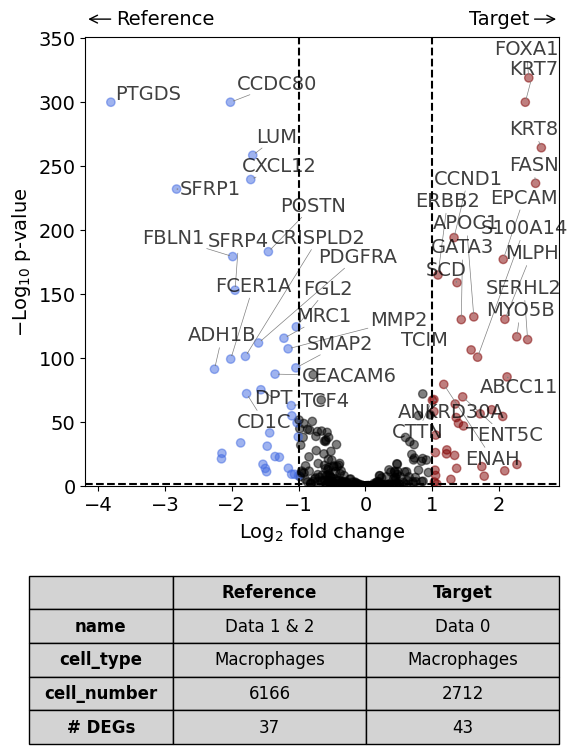

In [ ]:
dge_results = dge(
    target=xd0,
    ref=[xd1, xd2],
    target_name="Data 0",
    ref_name="Data 1 & 2",
    target_cell_type_tuple=("cell_type_dc_sub_final", "Macrophages"),
    ref_cell_type_tuple="same",
    exclude_ambiguous_assignments=False, # if a cell is assigned to both the annotation and the reference, it is used only for the annotation
)

volcano(dge_results, label_sortby="scores", show_config=True)

##### Scenario 1.2: Using the `InSituExperiment` objects

Instead of extracting the `InSituData` objects first, we can also perform the DGE analysis directly on the `InSituExperiment` object using its `dge()` function.

This has the big advantage that the function has direct access to the metadata stored in `InSituExperiment`, which allows the results to be directly linked to the respective data via its unique ID. All metadata is stored in the `DiffExprResults` object.

# Add that UID and metadata are saved in `DiffExprResults`/Config collector

In [154]:
exp.metadata

You are accessing a copy of the metadata. Changes to this DataFrame will not affect the internal metadata. Use `add_metadata_column()` or `append_metadata()` to add new information to the metadata.


,uid,slide_id,sample_id,region_key,region_name
0,d4604f2f,0001879,Replicate 1,Demo,Region 1
1,724eed1f,0001879,Replicate 1,Demo,Region 2
2,e7843434,0001879,Replicate 1,Demo,Region 3


##### With one reference dataset

Calculate differentially expressed genes with Scanpy's `rank_genes_groups` using 't-test'.


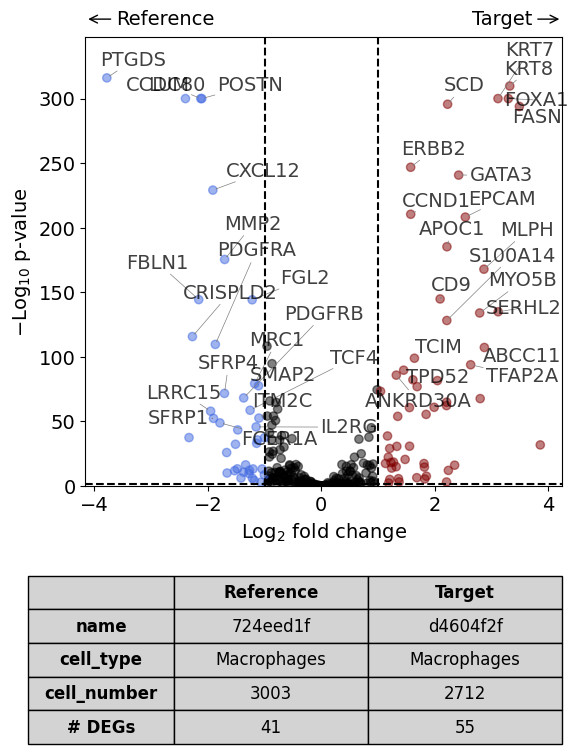

In [169]:
dge_results = exp.dge(
    target_id=0,
    ref_id=1,
    target_cell_type_tuple=("cell_type_dc_sub_final", "Macrophages"),
    ref_cell_type_tuple="same",
    exclude_ambiguous_assignments=False,
    # name_col="region_name"
)

volcano(dge_results, label_sortby="scores", show_config=True)

When using an `InSituExperiment` for differential gene expression analysis, all metadata is saved in `.config` of `DiffExprResults`:

In [174]:
print(dge_results.config)

DiffExprConfigCollector(
  General:
    type: single-cell
    method: t-test
    cells_layer: None
    exclude_ambiguous_assignments: False
  Target:
    annotation: None
    cell_type: Macrophages
    region: None
    cell_number: 2712
    name: d4604f2f
    metadata: {'uid': 'd4604f2f', 'slide_id': '0001879', 'sample_id': 'Replicate 1', 'region_key': 'Demo', 'region_name': 'Region 1'}
  Reference:
    annotation: None
    cell_type: Macrophages
    region: None
    cell_number: 3003
    name: 724eed1f
    metadata: {'uid': '724eed1f', 'slide_id': '0001879', 'sample_id': 'Replicate 1', 'region_key': 'Demo', 'region_name': 'Region 2'}
)


##### With list of reference datasets

Calculate differentially expressed genes with Scanpy's `rank_genes_groups` using 't-test'.


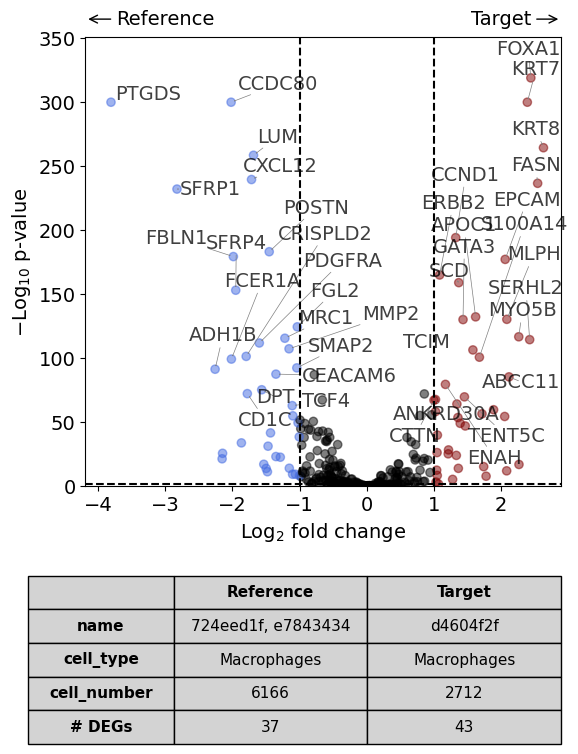

In [177]:
dge_results = exp.dge(
    target_id=0,
    ref_id=[1,2],
    target_cell_type_tuple=("cell_type_dc_sub_final", "Macrophages"),
    ref_cell_type_tuple="same",
    # name_col="region_name"
)

volcano(dge_results, label_sortby="scores", show_config=True)


##### Against all other datasets as reference using `"rest"` argument

This should result in the same plot as the previous analysis.

Calculate differentially expressed genes with Scanpy's `rank_genes_groups` using 't-test'.


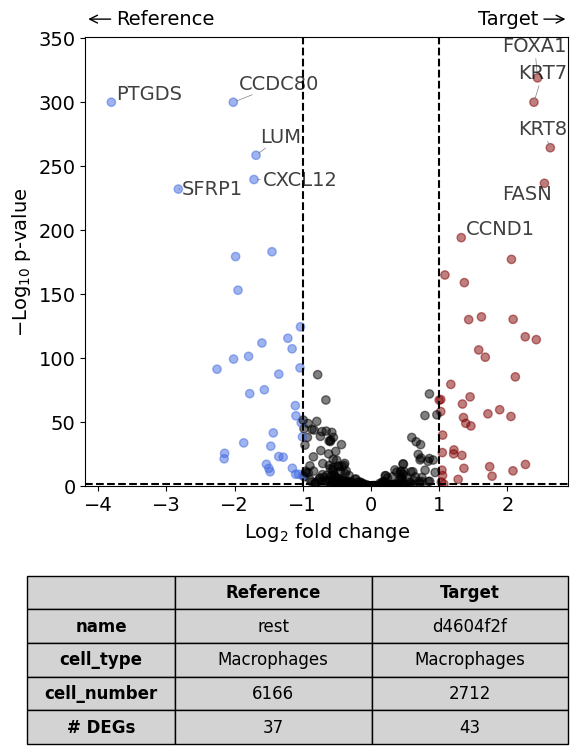

In [190]:
dge_results = exp.dge(
    target_id=0,
    ref_id="rest",
    target_cell_type_tuple=("cell_type_dc_sub_final", "Macrophages"),
    ref_cell_type_tuple="same",
    exclude_ambiguous_assignments=True,
)

volcano(
    dge_results,
    label_sortby="scores",
    show_config=True,
    label_top_n=5,
    savepath="figures/dge_demo_region1_vs_rest.pdf"
    )

Since "rest" can be a large list of files, the individual unique IDs are not shown in the config table. However, they are saved in `.config` of the `DiffExprResults`:

In [191]:
dge_results.config

DiffExprConfigCollector(
  General:
    type: single-cell
    method: t-test
    cells_layer: None
    exclude_ambiguous_assignments: True
  Target:
    annotation: None
    cell_type: Macrophages
    region: None
    cell_number: 2712
    name: d4604f2f
    metadata: {'uid': 'd4604f2f', 'slide_id': '0001879', 'sample_id': 'Replicate 1', 'region_key': 'Demo', 'region_name': 'Region 1'}
  Reference:
    annotation: None
    cell_type: Macrophages
    region: None
    cell_number: 6166
    name: rest
    metadata: {'uid': ['724eed1f', 'e7843434'], 'slide_id': ['0001879', '0001879'], 'sample_id': ['Replicate 1', 'Replicate 1'], 'region_key': ['Demo', 'Demo'], 'region_name': ['Region 2', 'Region 3']}
)

Calculate differentially expressed genes with Scanpy's `rank_genes_groups` using 't-test'.


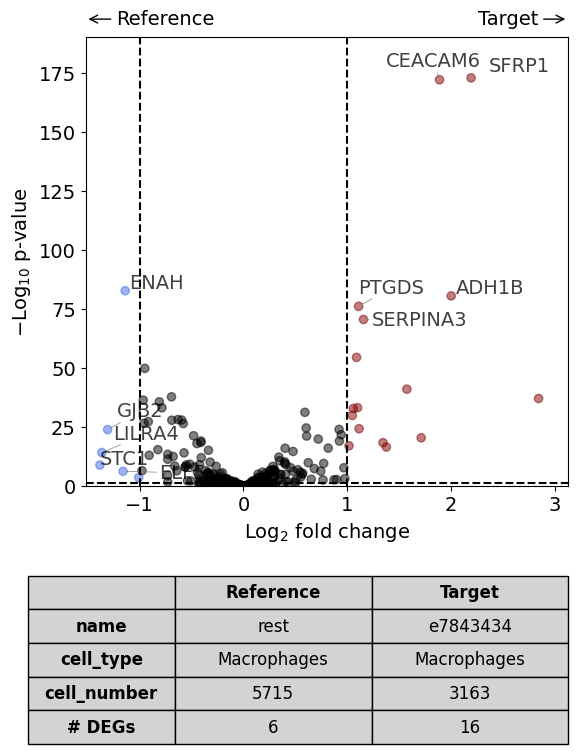

In [193]:
dge_results = exp.dge(
    target_id=2,
    ref_id="rest",
    target_cell_type_tuple=("cell_type_dc_sub_final", "Macrophages"),
    ref_cell_type_tuple="same",
    exclude_ambiguous_assignments=True
)

volcano(
    dge_results,
    label_sortby="scores",
    show_config=True,
    label_top_n=5,
    savepath="figures/dge_demo_region3_vs_rest.pdf"
    )

#### Scenario 2: Comparison of cells within one annotation against all other annotations - all within the same dataset

##### Scenario 2.1: Perform analysis without specifying a cell type

This scenario is only uses one dataset but also works on the `InSituExperiment` level.

Exclude ambiguously assigned cells...
Calculate differentially expressed genes with Scanpy's `rank_genes_groups` using 't-test'.


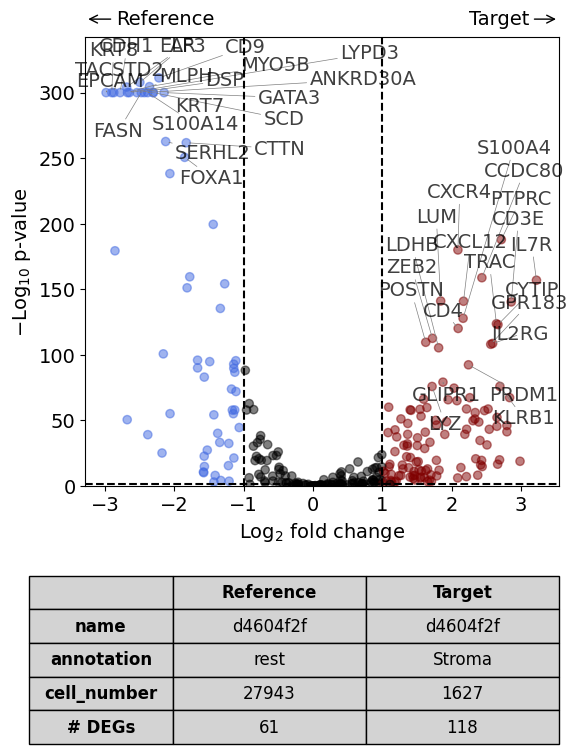

In [195]:
dge_results = exp.dge(
    target_id=0,
    target_annotation_tuple=("Demo", "Stroma"),
    ref_annotation_tuple="rest",
    exclude_ambiguous_assignments=True,
)

volcano(dge_results, label_sortby="scores", show_config=True)

##### Scenario 2.2: Perform analysis for one cell type only

This scenario is very similar to the first but the analysis is restricted to only one cell type (in this case Fibroblasts).

Calculate differentially expressed genes with Scanpy's `rank_genes_groups` using 't-test'.


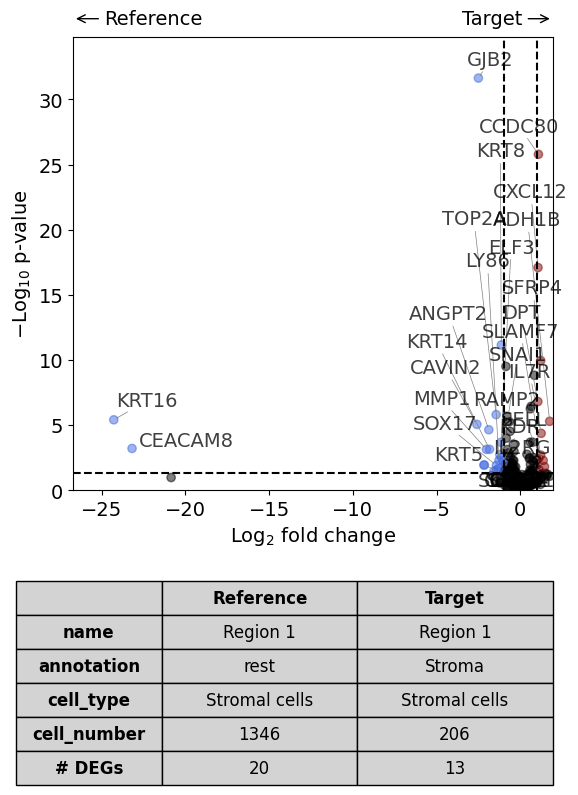

In [196]:
dge_results = exp.dge(
    target_id=0,
    target_annotation_tuple=("Demo", "Stroma"),
    ref_annotation_tuple="rest",
    target_cell_type_tuple=("cell_type_dc_sub_final", "Stromal cells"),
    ref_cell_type_tuple="same",
    name_col="region_name",
)

volcano(dge_results, label_sortby="scores", show_config=True)

#### Scenario 3: Comparison of two annotations between two regions or datasets - restrict analysis to one cell type

Here we compare the gene expression of one particular cell type (Stromal cells) in one histological annotation (Stroma) between two datasets. Further, we save the plot as PDF and restrict the number of labelled genes to 5.

In [200]:
annotation = "Stroma"
cell_type = "Stromal cells"

Calculate differentially expressed genes with Scanpy's `rank_genes_groups` using 't-test'.


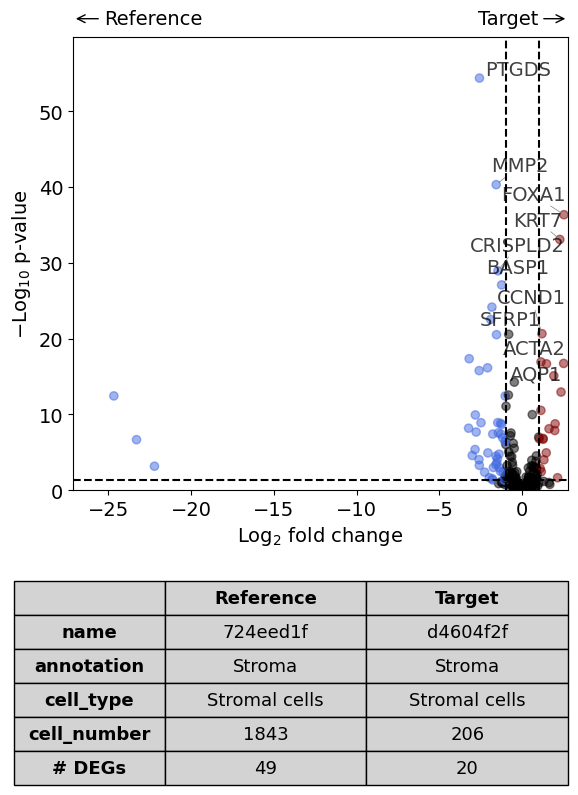

In [201]:

dge_results = exp.dge(
    target_id=0,
    ref_id=1,
    target_annotation_tuple=("Demo", annotation),
    ref_annotation_tuple=("Demo", annotation),
    target_cell_type_tuple=("cell_type_dc_sub_final", cell_type),
    ref_cell_type_tuple="same",
)

volcano(
    dge_results,
    label_sortby="scores",
    show_config=True,
    label_top_n=5,
    savepath="figures/volcano_demo.pdf"
    )

## GO term enrichment analysis

Gene ontology (GO) term enrichment analysis can be performed via three different analysis platforms: [g:Profiler](https://biit.cs.ut.ee/gprofiler/gost) and [Enrichr](https://maayanlab.cloud/Enrichr/).

As explained [here](https://biit.cs.ut.ee/gprofiler/page/docs#statistical_domain_scope) in case of panel-based technologies such as Xenium it is important to us a custom background gene list for the statistical analysis instead of all possible genes. Here, we used the overall gene list for this.

[STRINGdb](https://string-db.org/) is also implemented but does not allow to limit the background gene list. Therefore, this tool is not recommended to be used for Xenium data.

⚠️ **Attention**: Due to the low number of genes in a normal Xenium run, using GO term enrichment analysis with such datasets can be problematic. Please get in contact with statisticians to make sure it is ok to use this method with your data.

In [39]:
from insitupy.utils.go import GOEnrichment, get_up_down_genes
from insitupy.plotting.go import go_plot

In [41]:
genes_up, genes_down = get_up_down_genes(
    dge_results, pval_threshold=0.05, logfold_threshold=1)

In [42]:
background_genes = exp.data[0].cells.matrix.var_names.tolist()

In [43]:
# setup go term enrichment class
go = GOEnrichment()

# run go term enrichment analysis for up-regulated genes
go.gprofiler(target_genes=genes_up, key_added='up',
             top_n=20, organism="hsapiens", return_df=False,
             background=background_genes
             )
go.enrichr(target_genes=genes_up, key_added='up',
             top_n=20, organism="human", return_df=False,
             background=background_genes
             )

# for down-regulated genes
go.gprofiler(target_genes=genes_down, key_added='down',
             top_n=20, organism="hsapiens", return_df=False,
             background=background_genes
             )
go.enrichr(target_genes=genes_down, key_added='down',
             top_n=20, organism="human", return_df=False,
             background=background_genes
             )

The results are saved in the `GOEnrichment` class and can be accessed with the respective keys.

In [44]:
go

GOEnrichment analyses performed:
  gprofiler:
    - up
    - down
  enrichr:
    - up
    - down

Gprofiler does not return any significant results.

In [45]:
enrichment = go.results["gprofiler"]["up"]
enrichment.head()

,,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,Gene ratio,query,parents,intersections,evidences,Enrichment score


In [46]:
enrichment = go.results["gprofiler"]["down"]
enrichment.head()

,,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,Gene ratio,query,parents,intersections,evidences,Enrichment score


Enrichr does return significant results (before multiple testing correction).

In [47]:
enrichment = go.results["enrichr"]["down"]
enrichment.head()

source  \
query 0  GO_Biological_Process_2025   
      1  GO_Biological_Process_2025   
      2  GO_Biological_Process_2025   
      3  GO_Biological_Process_2025   
      4  GO_Biological_Process_2025   

                                                      name   P-value  \
query 0                   Negative Regulation of Signaling  0.004322   
      1          Negative Regulation of Cell Communication  0.004322   
      2                      Fc Receptor Signaling Pathway  0.038175   
      3  Positive Regulation of Cold-Induced Thermogenesis  0.038175   
      4                Cytokine-Mediated Signaling Pathway  0.048466   

         Adjusted P-value  Old P-value  Old adjusted P-value  Odds Ratio  \
query 0          0.308539            0                     0         inf   
      1          0.308539            0                     0         inf   
      2          0.308539            0                     0   10.148148   
      3          0.308539            0                     0   10.148148   
      4          0.308539            0                     0    4.711765   

         Combined Score           intersections  Enrichment score      native  
query 0             inf           [ADIPOQ, LIF]           0.51069  GO:0023057  
      1             inf           [ADIPOQ, LIF]           0.51069  GO:0010648  
      2       33.139449          [PIGR, LILRA4]           0.51069  GO:0038093  
      3       33.139449          [OXTR, ADIPOQ]           0.51069  GO:0120162  
      4       14.262026  [CCL8, ADIPOQ, LILRA4]           0.51069  GO:0019221

In [48]:
enrichment = go.results["enrichr"]["up"]
enrichment.head()

source  \
query 101  GO_Biological_Process_2025   
      100  GO_Biological_Process_2025   
      99   GO_Biological_Process_2025   
      98   GO_Biological_Process_2025   
      97   GO_Biological_Process_2025   

                                                        name  P-value  \
query 101  Negative Regulation of Cell-Cell Adhesion Medi...  0.06734   
      100          Negative Regulation of Cell-Cell Adhesion  0.06734   
      99                               Leukotriene Transport  0.06734   
      98                    Norepinephrine Metabolic Process  0.06734   
      97                   Negative Regulation of Cell Cycle  0.06734   

           Adjusted P-value  Old P-value  Old adjusted P-value  Odds Ratio  \
query 101          0.185515            0                     0         inf   
      100          0.185515            0                     0         inf   
      99           0.185515            0                     0         inf   
      98           0.185515            0                     0         inf   
      97           0.185515            0                     0         inf   

           Combined Score intersections  Enrichment score      native  
query 101             inf       [EPCAM]          0.731622  GO:2000048  
      100             inf       [EPCAM]          0.731622  GO:0022408  
      99              inf      [ABCC11]          0.731622  GO:0071716  
      98              inf       [GATA3]          0.731622  GO:0042415  
      97              inf       [GATA3]          0.731622  GO:0045786

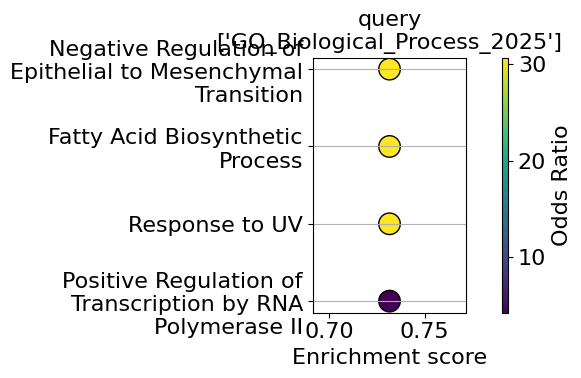

In [49]:
go_plot(enrichment=enrichment,
        style='dot',
        libraries='GO_Biological_Process_2025',
        color_key="Odds Ratio",
        max_to_plot=5,
        figsize=(6,4),
        #savepath="figures/go_demo.pdf"
        )

### GO term enrichment analysis for all three regions

In [50]:
up_list = []
down_list = []
for i in range(len(exp)):
    dge = exp.dge(
        target_id=i,
        ref_id="rest",
        target_cell_type_tuple=("cell_type_dc_sub", "Macrophages"),
        plot_volcano=False,
        return_results=True
    )
    genes_up, genes_down = get_up_down_genes(dge['results'], pval_threshold=0.05, logfold_threshold=1)
    up_list.append(genes_up)
    down_list.append(genes_down)

Calculate differentially expressed genes with Scanpy's `rank_genes_groups` using 't-test'.
Calculate differentially expressed genes with Scanpy's `rank_genes_groups` using 't-test'.
Calculate differentially expressed genes with Scanpy's `rank_genes_groups` using 't-test'.


In [51]:
up_list

[['KRT7',
  'FOXA1',
  'KRT8',
  'FASN',
  'CCND1',
  'EPCAM',
  'ERBB2',
  'SCD',
  'MLPH',
  'APOC1',
  'GATA3',
  'MYO5B',
  'SERHL2',
  'TCIM',
  'S100A14',
  'ABCC11',
  'ENAH',
  'TENT5C',
  'ANKRD30A',
  'CTTN',
  'SH3YL1',
  'AR',
  'CD9',
  'TRAF4',
  'ELF3',
  'DSP',
  'TFAP2A',
  'PCLAF',
  'CDH1',
  'TOP2A',
  'KLF5',
  'OCIAD2',
  'CENPF',
  'STC1',
  'DMKN',
  'C6orf132',
  'TUBB2B',
  'ELF5',
  'LILRA4',
  'ESM1',
  'SOX17',
  'HPX',
  'SCGB2A1'],
 ['POSTN',
  'LUM',
  'CCDC80',
  'MMP2',
  'CXCL12',
  'CRISPLD2',
  'PDGFRB',
  'PDGFRA',
  'LRRC15',
  'MEDAG',
  'GJB2',
  'GZMB',
  'TCEAL7',
  'LTB'],
 ['SFRP1',
  'CEACAM6',
  'ADH1B',
  'PTGDS',
  'SERPINA3',
  'SFRP4',
  'KRT15',
  'OPRPN',
  'AQP1',
  'FCER1A',
  'CD1C',
  'LPL',
  'KRT23',
  'MMP12',
  'KRT14',
  'MYH11']]

In [52]:
# setup go term enrichment class
go = GOEnrichment()

for i, genes_up in enumerate(up_list):
    # run go term enrichment analysis for up-regulated genes
    go.enrichr(target_genes=genes_up, key_added=f'Region{i+1}_up',
                top_n=20, organism="Human", return_df=False,
                background=background_genes
                )

The results are saved in the `GOEnrichment` class and can be accessed with the respective keys.

In [53]:
go

GOEnrichment analyses performed:
  enrichr:
    - Region1_up
    - Region2_up
    - Region3_up

color_key 'Gene ratio' not found in columns.


C:\Users\ge37voy\Github\InSituPy\insitupy\plotting\go.py:140: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  s = axs[i].scatter(


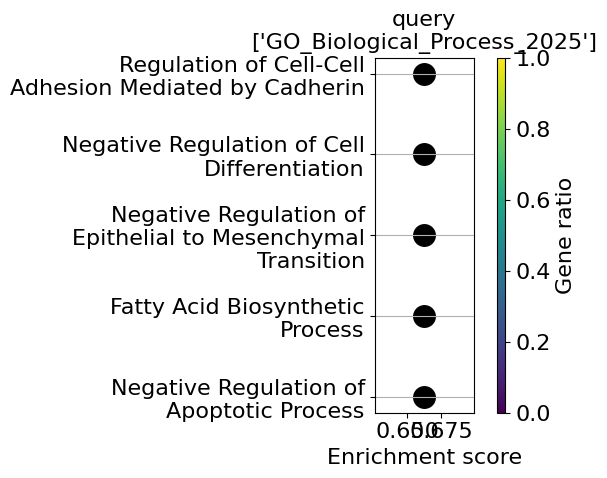

color_key 'Gene ratio' not found in columns.


C:\Users\ge37voy\Github\InSituPy\insitupy\plotting\go.py:140: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  s = axs[i].scatter(


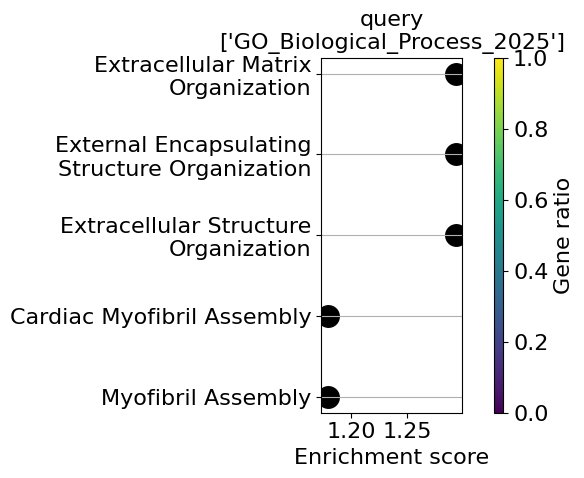

color_key 'Gene ratio' not found in columns.


C:\Users\ge37voy\Github\InSituPy\insitupy\plotting\go.py:140: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  s = axs[i].scatter(


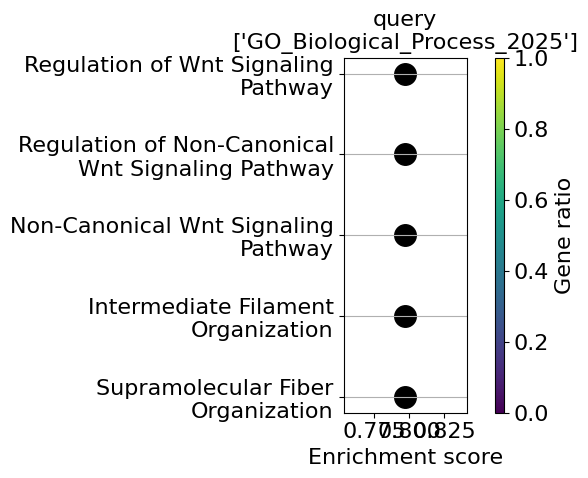

In [54]:
go_results = go.results["enrichr"]

for i, k in enumerate(go_results.keys()):
    enrichment = go_results[k]
    go_plot(enrichment=enrichment,
            style='dot',
            libraries='GO_Biological_Process_2025',
            max_to_plot=5,
            figsize=(6,5),
            #savepath=f"figures/go_demo_region{i+1}.pdf"
            )